In [ ]:
# Import required libraries
import os
import zipfile
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define dataset folder path
data_folder = "/content/drive/MyDrive/datasets/Employee Attrition Classification Dataset"

print("Dataset folder:", data_folder)
print("Folder exists:", os.path.exists(data_folder))

Dataset folder: /content/drive/MyDrive/datasets/Employee Attrition Classification Dataset
Folder exists: True


In [ ]:
# List files inside the dataset folder
for file_name in os.listdir(data_folder):
    print(file_name)

test.csv
train.csv


In [ ]:
# Define train and test file paths
train_path = os.path.join(data_folder, "train.csv")
test_path = os.path.join(data_folder, "test.csv")

print("Train path:", train_path)
print("Test path :", test_path)

if not os.path.exists(train_path):
    raise FileNotFoundError(f"train.csv not found at: {train_path}")

if not os.path.exists(test_path):
    raise FileNotFoundError(f"test.csv not found at: {test_path}")

Train path: /content/drive/MyDrive/datasets/Employee Attrition Classification Dataset/train.csv
Test path : /content/drive/MyDrive/datasets/Employee Attrition Classification Dataset/test.csv


In [ ]:
# Load datasets
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [ ]:
# Check dataset shapes
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (59598, 24)
Test shape : (14900, 24)


In [ ]:
# Preview first 5 rows
print("Train preview")
display(train_df.head())

print("Test preview")
display(test_df.head())

Train preview


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,No,22,Associate Degree,Married,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,No,21,Master’s Degree,Divorced,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,No,11,Bachelor’s Degree,Married,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,No,27,High School,Single,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,Yes,71,High School,Divorced,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


Test preview


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,52685,36,Male,13,Healthcare,8029,Excellent,High,Average,1,Yes,83,Master’s Degree,Married,1,Mid,Large,22,No,No,No,Poor,Medium,Stayed
1,30585,35,Male,7,Education,4563,Good,High,Average,1,Yes,55,Associate Degree,Single,4,Entry,Medium,27,No,No,No,Good,High,Left
2,54656,50,Male,7,Education,5583,Fair,High,Average,3,Yes,14,Associate Degree,Divorced,2,Senior,Medium,76,No,No,Yes,Good,Low,Stayed
3,33442,58,Male,44,Media,5525,Fair,Very High,High,0,Yes,43,Master’s Degree,Single,4,Entry,Medium,96,No,No,No,Poor,Low,Left
4,15667,39,Male,24,Education,4604,Good,High,Average,0,Yes,47,Master’s Degree,Married,6,Mid,Large,45,Yes,No,No,Good,High,Stayed


In [ ]:
# Print column names
print("Train columns:")
for i, col in enumerate(train_df.columns, 1):
    print(f"{i:02d}. {col}")

Train columns:
01. Employee ID
02. Age
03. Gender
04. Years at Company
05. Job Role
06. Monthly Income
07. Work-Life Balance
08. Job Satisfaction
09. Performance Rating
10. Number of Promotions
11. Overtime
12. Distance from Home
13. Education Level
14. Marital Status
15. Number of Dependents
16. Job Level
17. Company Size
18. Company Tenure
19. Remote Work
20. Leadership Opportunities
21. Innovation Opportunities
22. Company Reputation
23. Employee Recognition
24. Attrition


In [ ]:
# Dataset info
print("Train info")
train_df.info()

print("\nTest info")
test_df.info()

Train info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of D

In [ ]:
# Data type summary
dtype_summary = pd.DataFrame({
    "column": train_df.columns,
    "dtype": train_df.dtypes.values
})

display(dtype_summary)

,column,dtype
0,Employee ID,int64
1,Age,int64
2,Gender,object
3,Years at Company,int64
4,Job Role,object
5,Monthly Income,int64
6,Work-Life Balance,object
7,Job Satisfaction,object
8,Performance Rating,object
9,Number of Promotions,int64


In [ ]:
# Check missing values in training data and sort them in descending order
train_missing = train_df.isnull().sum().sort_values(ascending=False)

# Check missing values in test data and sort them in descending order
test_missing = test_df.isnull().sum().sort_values(ascending=False)

# Create a summary table for training data missing values
train_missing_df = pd.DataFrame({
    "missing_count": train_missing,
    "missing_percent": (train_missing / len(train_df)) * 100
})

# Create a summary table for test data missing values
test_missing_df = pd.DataFrame({
    "missing_count": test_missing,
    "missing_percent": (test_missing / len(test_df)) * 100
})

# Display only columns with missing values in training data
print("Train missing values")
display(train_missing_df[train_missing_df["missing_count"] > 0])

# Display only columns with missing values in test data
print("Test missing values")
display(test_missing_df[test_missing_df["missing_count"] > 0])

Train missing values


,missing_count,missing_percent


Test missing values


,missing_count,missing_percent


In [ ]:
# Duplicate rows check
train_duplicates = train_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()

print("Duplicate rows in train:", train_duplicates)
print("Duplicate rows in test :", test_duplicates)

Duplicate rows in train: 0
Duplicate rows in test : 0


In [ ]:
# Separate numerical columns from the dataset
numerical_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Separate categorical columns from the dataset
categorical_cols = train_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Print the number of numerical and categorical columns
print("Number of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

# Print the list of numerical columns
print("\nNumerical columns:")
print(numerical_cols)

# Print the list of categorical columns
print("\nCategorical columns:")
print(categorical_cols)

Number of numerical columns: 8
Number of categorical columns: 16

Numerical columns:
['Employee ID', 'Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure']

Categorical columns:
['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition']


In [ ]:
# Inspect possible target candidates
possible_target_info = pd.DataFrame({
    "column": train_df.columns,
    "n_unique": [train_df[col].nunique() for col in train_df.columns],
    "dtype": [train_df[col].dtype for col in train_df.columns]
}).sort_values(by=["n_unique", "column"])

display(possible_target_info.head(20))

,column,n_unique,dtype
23,Attrition,2,object
2,Gender,2,object
20,Innovation Opportunities,2,object
19,Leadership Opportunities,2,object
10,Overtime,2,object
18,Remote Work,2,object
16,Company Size,3,object
15,Job Level,3,object
13,Marital Status,3,object
21,Company Reputation,4,object


In [ ]:
# Inspect low-cardinality columns
low_cardinality_cols = [col for col in train_df.columns if train_df[col].nunique() <= 10]

for col in low_cardinality_cols:
    print("\nColumn:", col)
    print("Unique values:", train_df[col].nunique())
    print(train_df[col].value_counts(dropna=False))


Column: Gender
Unique values: 2
Gender
Male      32739
Female    26859
Name: count, dtype: int64

Column: Job Role
Unique values: 5
Job Role
Technology    15507
Healthcare    13642
Education     12490
Media          9574
Finance        8385
Name: count, dtype: int64

Column: Work-Life Balance
Unique values: 4
Work-Life Balance
Good         22528
Fair         18046
Excellent    10719
Poor          8305
Name: count, dtype: int64

Column: Job Satisfaction
Unique values: 4
Job Satisfaction
High         29779
Very High    12111
Medium       11817
Low           5891
Name: count, dtype: int64

Column: Performance Rating
Unique values: 4
Performance Rating
Average          35810
High             11888
Below Average     8950
Low               2950
Name: count, dtype: int64

Column: Number of Promotions
Unique values: 5
Number of Promotions
0    29716
1    14965
2    10884
3     3245
4      788
Name: count, dtype: int64

Column: Overtime
Unique values: 2
Overtime
No     40148
Yes    19450
Name:

In [ ]:
# Feature summary
feature_summary = pd.DataFrame({
    "column": train_df.columns,
    "dtype": train_df.dtypes.values,
    "missing_count": train_df.isnull().sum().values,
    "missing_percent": (train_df.isnull().sum().values / len(train_df)) * 100,
    "n_unique": [train_df[col].nunique() for col in train_df.columns]
})

display(feature_summary)

,column,dtype,missing_count,missing_percent,n_unique
0,Employee ID,int64,0,0.0,59598
1,Age,int64,0,0.0,42
2,Gender,object,0,0.0,2
3,Years at Company,int64,0,0.0,51
4,Job Role,object,0,0.0,5
5,Monthly Income,int64,0,0.0,9569
6,Work-Life Balance,object,0,0.0,4
7,Job Satisfaction,object,0,0.0,4
8,Performance Rating,object,0,0.0,4
9,Number of Promotions,int64,0,0.0,5


In [ ]:
# Check train/test column consistency
train_cols_set = set(train_df.columns)
test_cols_set = set(test_df.columns)

print("Only in train:", list(train_cols_set - test_cols_set))
print("Only in test :", list(test_cols_set - train_cols_set))
print("Column order matches:", list(train_df.columns) == list(test_df.columns))

Only in train: []
Only in test : []
Column order matches: True


**Target confirmation, feature classification, and core EDA**

In [ ]:
# Confirm target column candidates with very low unique values
target_candidate_df = pd.DataFrame({
    "column": train_df.columns,
    "n_unique": [train_df[col].nunique() for col in train_df.columns],
    "unique_values": [list(train_df[col].dropna().unique()[:10]) for col in train_df.columns]
}).sort_values(by=["n_unique", "column"])

display(target_candidate_df.head(24))

,column,n_unique,unique_values
23,Attrition,2,"[Stayed, Left]"
2,Gender,2,"[Male, Female]"
20,Innovation Opportunities,2,"[No, Yes]"
19,Leadership Opportunities,2,"[No, Yes]"
10,Overtime,2,"[No, Yes]"
18,Remote Work,2,"[No, Yes]"
16,Company Size,3,"[Medium, Small, Large]"
15,Job Level,3,"[Mid, Senior, Entry]"
13,Marital Status,3,"[Married, Divorced, Single]"
21,Company Reputation,4,"[Excellent, Fair, Poor, Good]"


In [ ]:

target_col = "Attrition"

print("Selected target column:", target_col)
print("Target present in train:", target_col in train_df.columns)
print("Target present in test :", target_col in test_df.columns)

Selected target column: Attrition
Target present in train: True
Target present in test : True


In [ ]:
# Separate features and target variable from training data
X_train_full = train_df.drop(columns=[target_col]).copy()
y_train_full = train_df[target_col].copy()

# Separate features and target variable from test data
X_test_full = test_df.drop(columns=[target_col]).copy()
y_test_full = test_df[target_col].copy()

# Print shapes of training features and target
print("X_train_full shape:", X_train_full.shape)
print("y_train_full shape:", y_train_full.shape)

# Print shapes of test features and target
print("X_test_full shape :", X_test_full.shape)
print("y_test_full shape :", y_test_full.shape)

X_train_full shape: (59598, 23)
y_train_full shape: (59598,)
X_test_full shape : (14900, 23)
y_test_full shape : (14900,)


In [ ]:
# Reclassify numerical and categorical feature columns after removing target
numerical_features = X_train_full.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train_full.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 8
Number of categorical features: 15

Numerical features:
['Employee ID', 'Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure']

Categorical features:
['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']


In [ ]:
# Create a feature classification table
feature_classification_df = pd.DataFrame({
    "feature": X_train_full.columns,
    "dtype": X_train_full.dtypes.values,
    "n_unique": [X_train_full[col].nunique() for col in X_train_full.columns],
    "missing_count": [X_train_full[col].isnull().sum() for col in X_train_full.columns],
    "missing_percent": [(X_train_full[col].isnull().sum() / len(X_train_full)) * 100 for col in X_train_full.columns]
})

display(feature_classification_df.sort_values(by=["dtype", "n_unique"]))

,feature,dtype,n_unique,missing_count,missing_percent
9,Number of Promotions,int64,5,0,0.0
14,Number of Dependents,int64,7,0,0.0
1,Age,int64,42,0,0.0
3,Years at Company,int64,51,0,0.0
11,Distance from Home,int64,99,0,0.0
17,Company Tenure,int64,127,0,0.0
5,Monthly Income,int64,9569,0,0.0
0,Employee ID,int64,59598,0,0.0
2,Gender,object,2,0,0.0
10,Overtime,object,2,0,0.0


In [ ]:
# Check target distribution
target_distribution = y_train_full.value_counts(dropna=False)
target_percentage = y_train_full.value_counts(normalize=True, dropna=False) * 100

target_summary_df = pd.DataFrame({
    "count": target_distribution,
    "percentage": target_percentage.round(2)
})

display(target_summary_df)

,count,percentage
Attrition,,
Stayed,31260,52.45
Left,28338,47.55


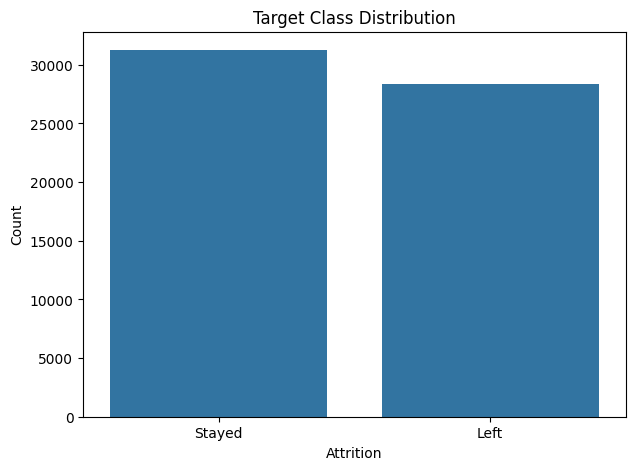

In [ ]:
# Plot target class distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(x=y_train_full)
plt.title("Target Class Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

In [ ]:
# Print class imbalance ratio
majority_class_count = y_train_full.value_counts().max()
minority_class_count = y_train_full.value_counts().min()
imbalance_ratio = majority_class_count / minority_class_count

print("Majority class count:", majority_class_count)
print("Minority class count:", minority_class_count)
print("Imbalance ratio:", round(imbalance_ratio, 2))

Majority class count: 31260
Minority class count: 28338
Imbalance ratio: 1.1


In [ ]:
# Inspect categorical feature cardinality
categorical_cardinality_df = pd.DataFrame({
    "feature": categorical_features,
    "n_unique": [X_train_full[col].nunique() for col in categorical_features]
}).sort_values(by="n_unique", ascending=False)

display(categorical_cardinality_df)

,feature,n_unique
1,Job Role,5
6,Education Level,5
2,Work-Life Balance,4
4,Performance Rating,4
3,Job Satisfaction,4
14,Employee Recognition,4
13,Company Reputation,4
9,Company Size,3
8,Job Level,3
7,Marital Status,3


In [ ]:
# Show unique values for categorical columns with low to medium cardinality
for col in categorical_features:
    if X_train_full[col].nunique() <= 15:
        print(f"\nFeature: {col}")
        print(X_train_full[col].value_counts(dropna=False))


Feature: Gender
Gender
Male      32739
Female    26859
Name: count, dtype: int64

Feature: Job Role
Job Role
Technology    15507
Healthcare    13642
Education     12490
Media          9574
Finance        8385
Name: count, dtype: int64

Feature: Work-Life Balance
Work-Life Balance
Good         22528
Fair         18046
Excellent    10719
Poor          8305
Name: count, dtype: int64

Feature: Job Satisfaction
Job Satisfaction
High         29779
Very High    12111
Medium       11817
Low           5891
Name: count, dtype: int64

Feature: Performance Rating
Performance Rating
Average          35810
High             11888
Below Average     8950
Low               2950
Name: count, dtype: int64

Feature: Overtime
Overtime
No     40148
Yes    19450
Name: count, dtype: int64

Feature: Education Level
Education Level
Bachelor’s Degree    17826
Associate Degree     14915
Master’s Degree      12020
High School          11748
PhD                   3089
Name: count, dtype: int64

Feature: Marital Sta

In [ ]:
# Numerical summary statistics
numerical_summary_df = X_train_full[numerical_features].describe().T
display(numerical_summary_df)

,count,mean,std,min,25%,50%,75%,max
Employee ID,59598.0,37227.118729,21519.150028,1.0,18580.25,37209.5,55876.75,74498.0
Age,59598.0,38.565875,12.079673,18.0,28.00,39.0,49.00,59.0
Years at Company,59598.0,15.753901,11.245981,1.0,7.00,13.0,23.00,51.0
Monthly Income,59598.0,7302.397983,2151.457423,1316.0,5658.00,7354.0,8880.00,16149.0
Number of Promotions,59598.0,0.832578,0.994991,0.0,0.00,1.0,2.00,4.0
Distance from Home,59598.0,50.007651,28.466459,1.0,25.00,50.0,75.00,99.0
Number of Dependents,59598.0,1.648075,1.555689,0.0,0.00,1.0,3.00,6.0
Company Tenure,59598.0,55.758415,25.411090,2.0,36.00,56.0,76.00,128.0


In [ ]:
# Check skewness of numerical features
skewness_df = pd.DataFrame({
    "feature": numerical_features,
    "skewness": [X_train_full[col].skew() for col in numerical_features]
}).sort_values(by="skewness", ascending=False)

display(skewness_df)

,feature,skewness
4,Number of Promotions,0.993426
2,Years at Company,0.788144
6,Number of Dependents,0.715559
3,Monthly Income,0.115091
7,Company Tenure,0.066688
5,Distance from Home,0.002879
0,Employee ID,0.002807
1,Age,-0.007047


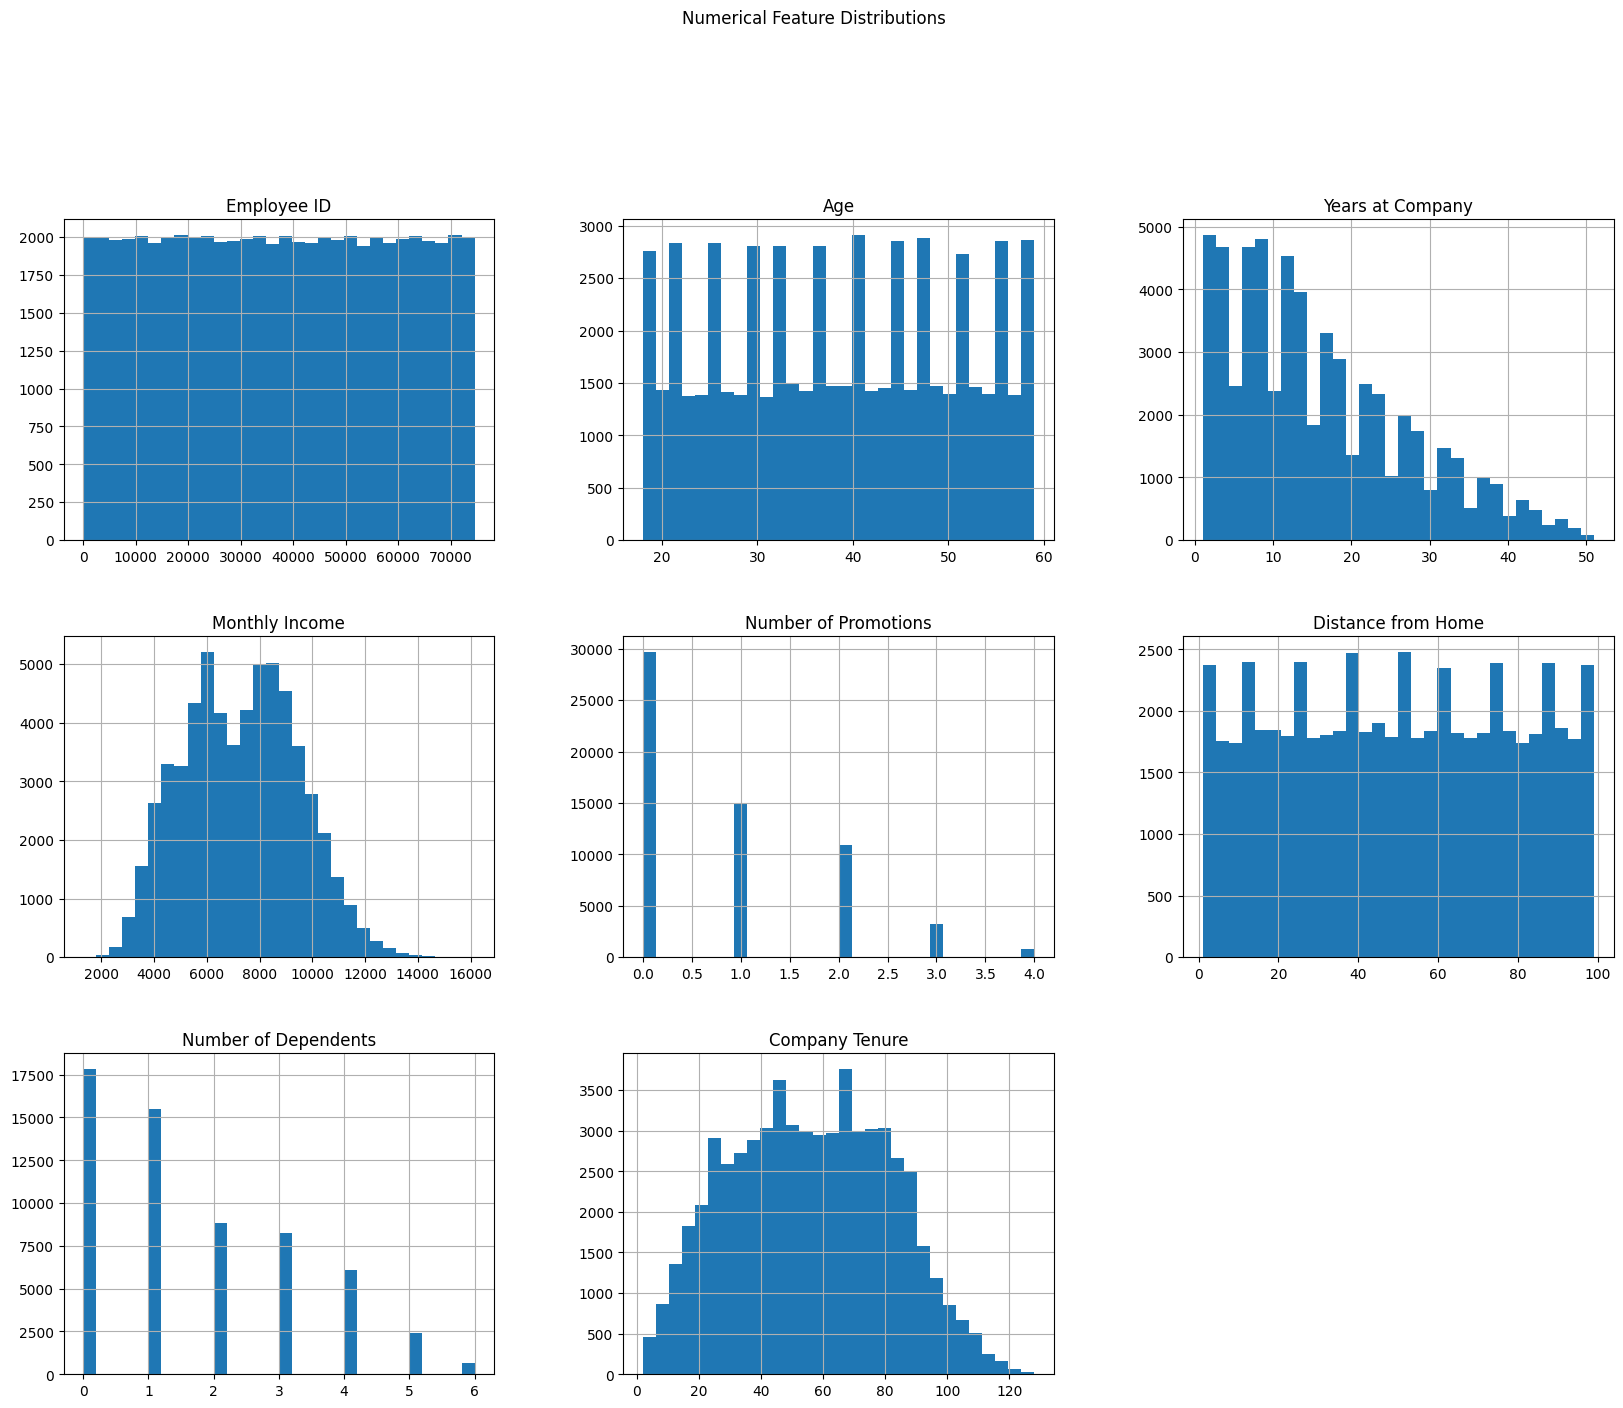

In [ ]:
# Plot histograms for numerical features
X_train_full[numerical_features].hist(figsize=(20, 15), bins=30)
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.show()

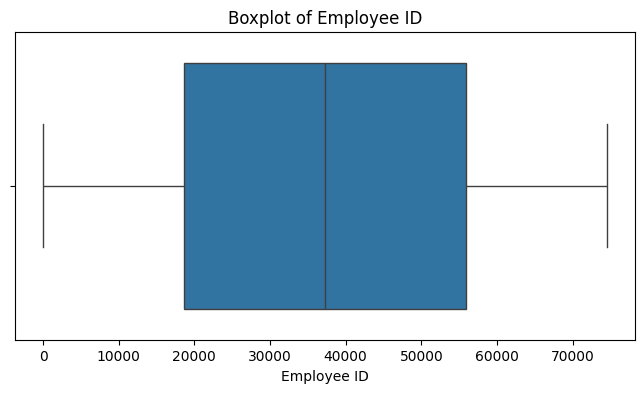

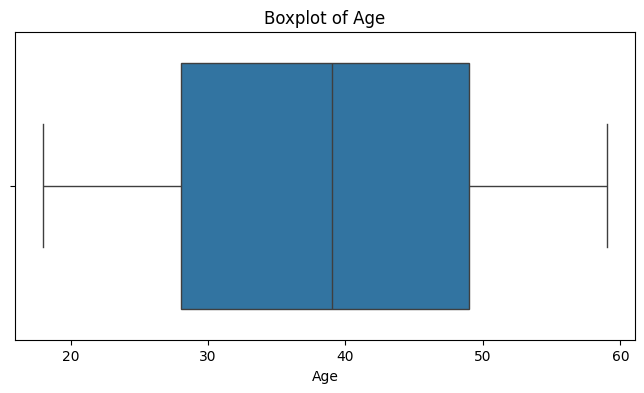

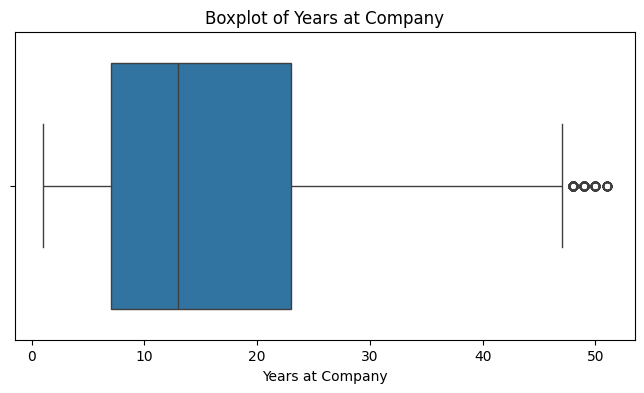

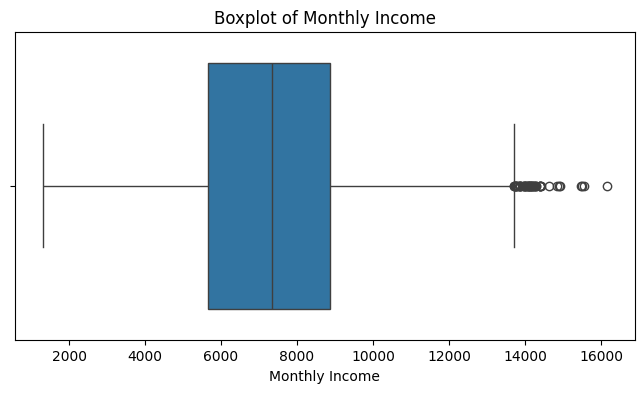

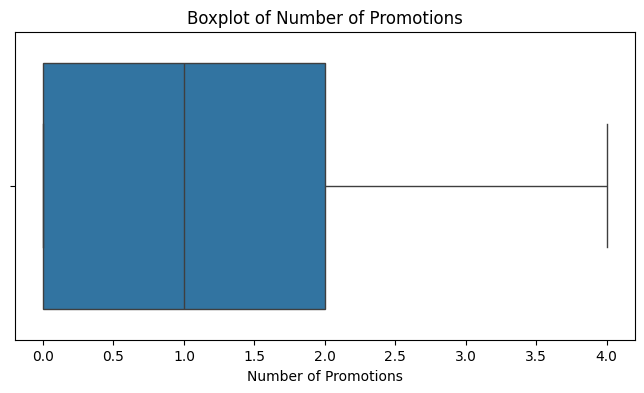

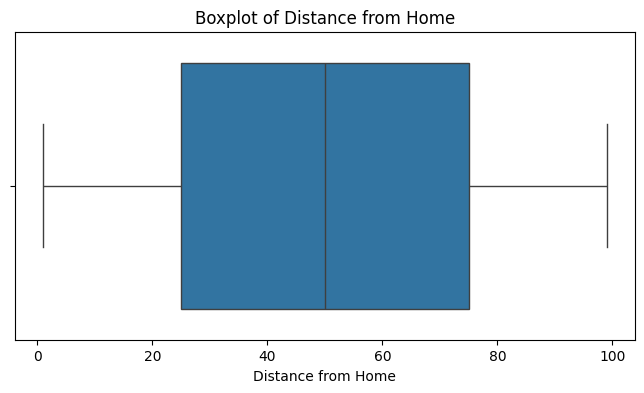

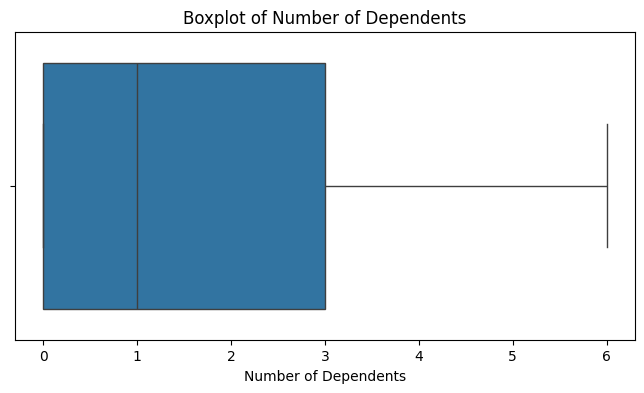

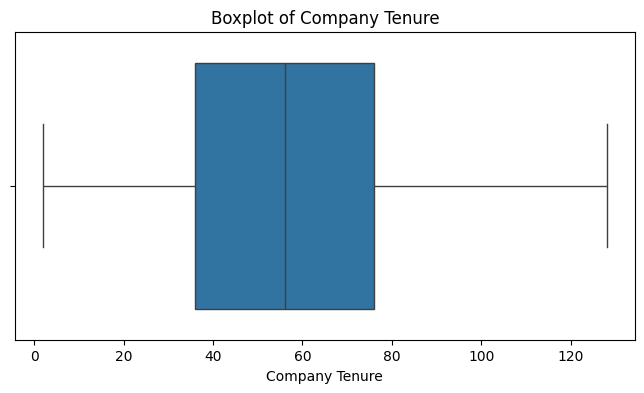

In [ ]:
# Boxplots for numerical features
for col in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=X_train_full[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

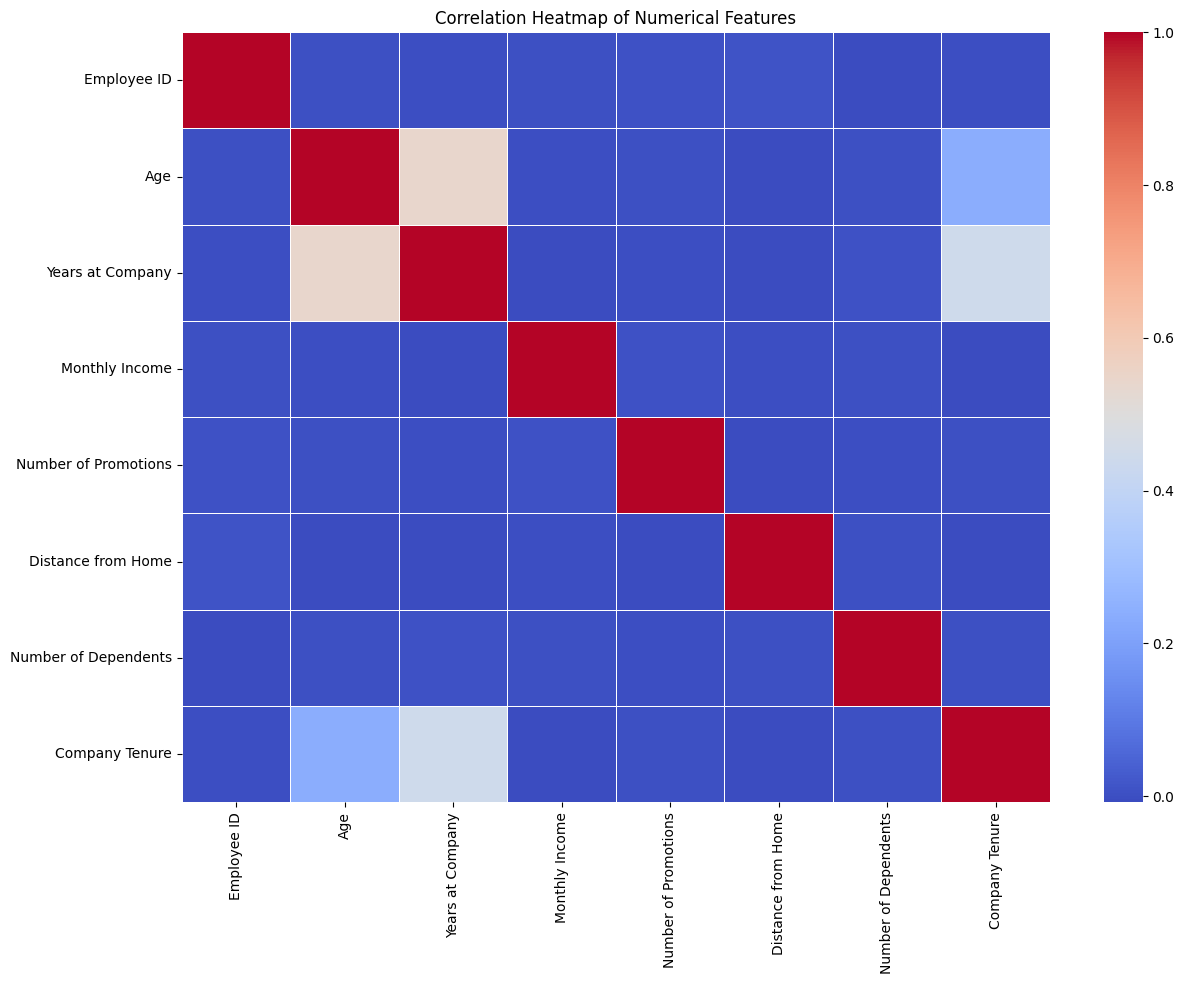

In [ ]:
# Correlation matrix for numerical features
corr_matrix = X_train_full[numerical_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

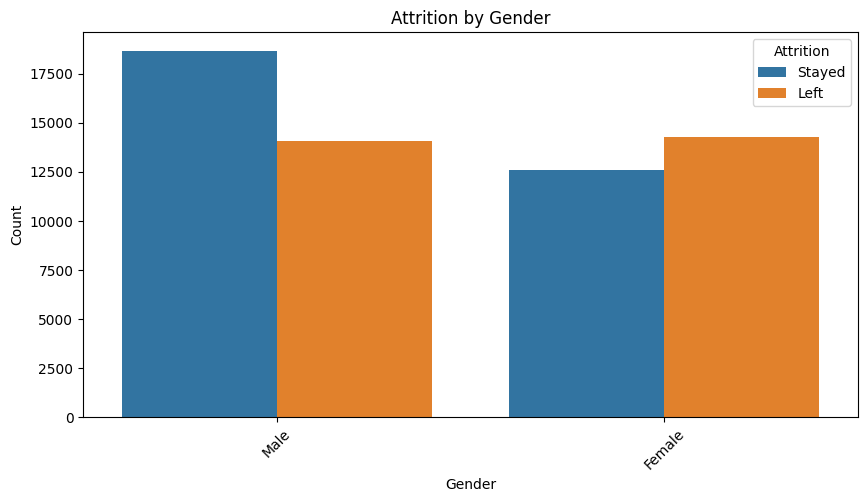

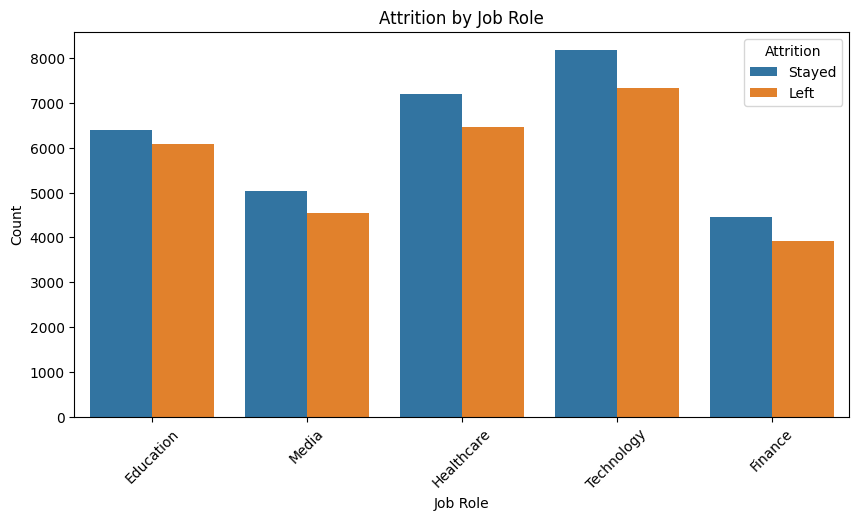

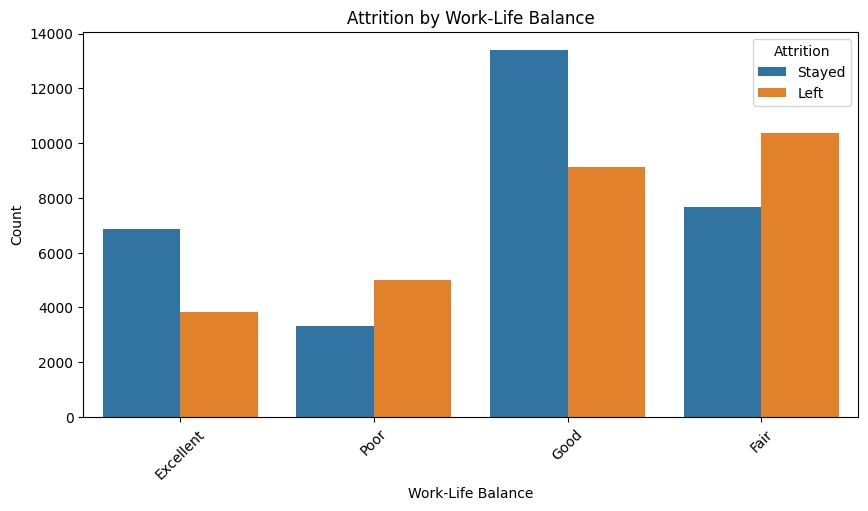

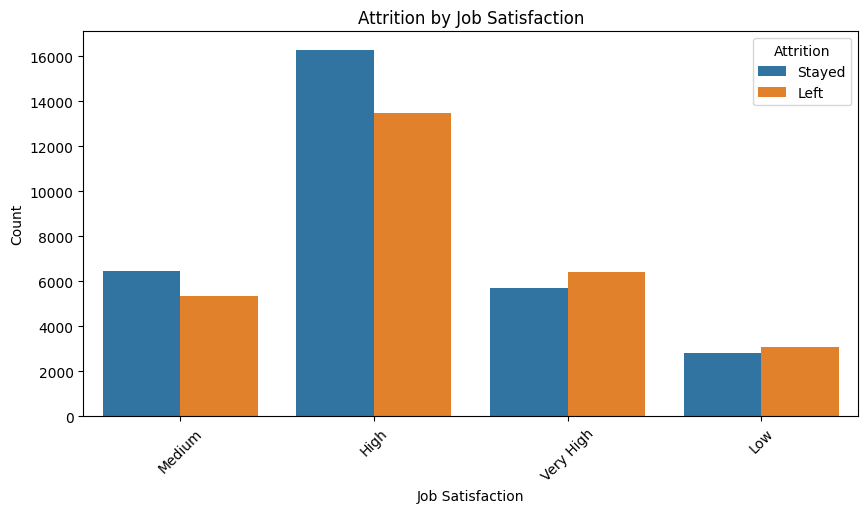

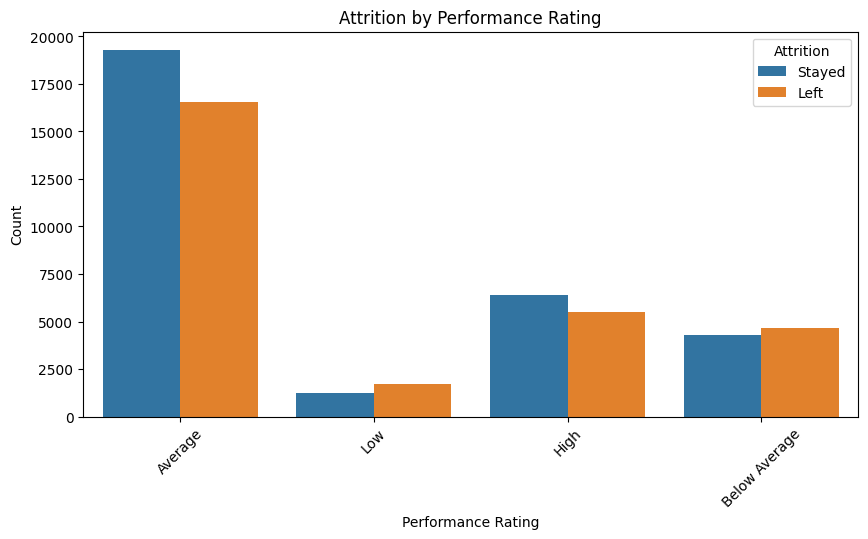

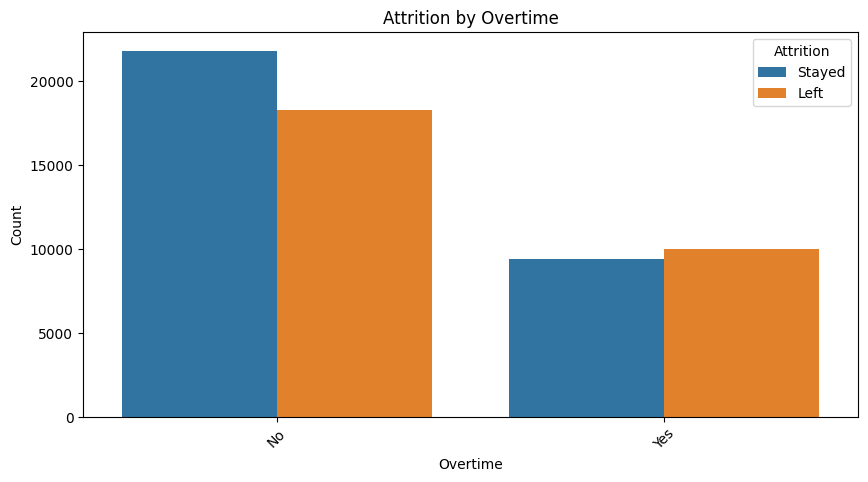

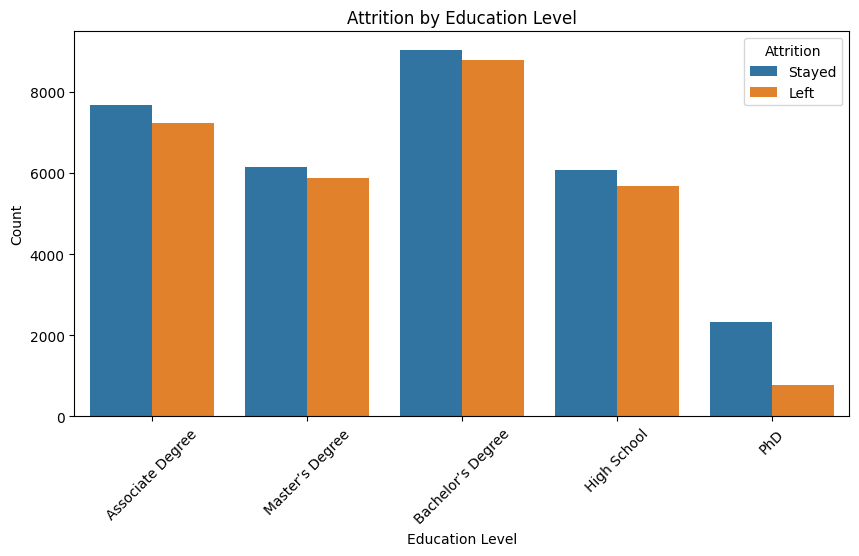

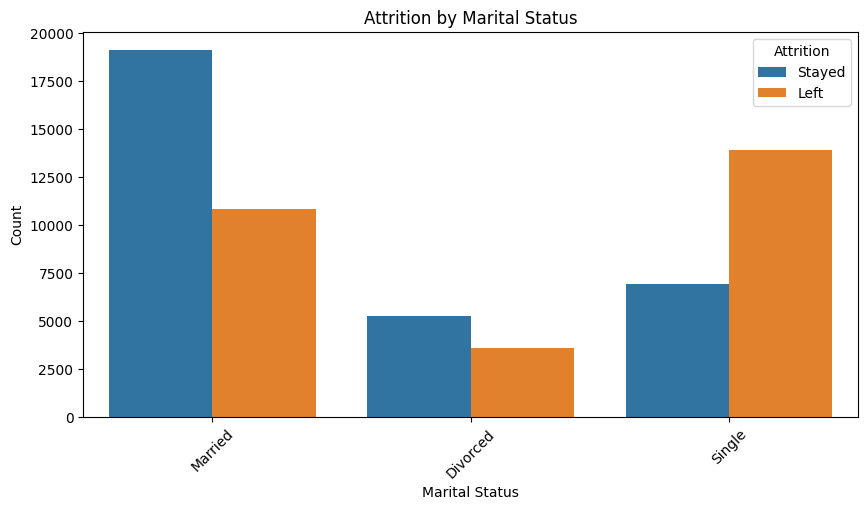

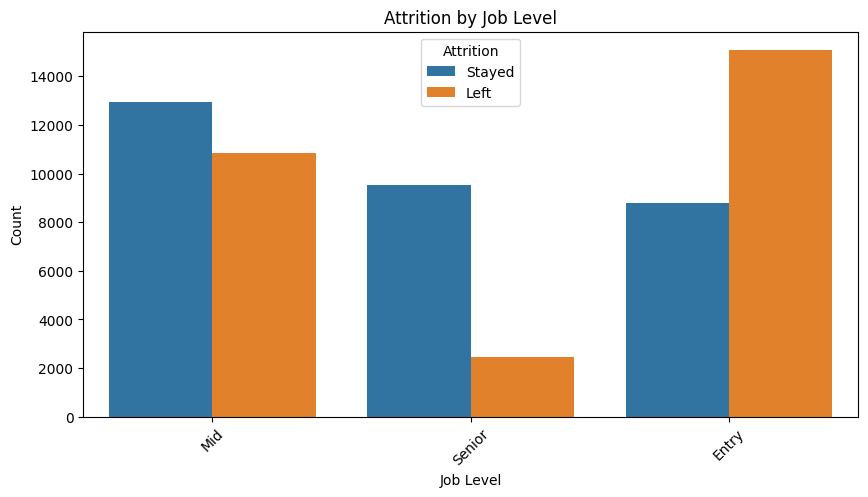

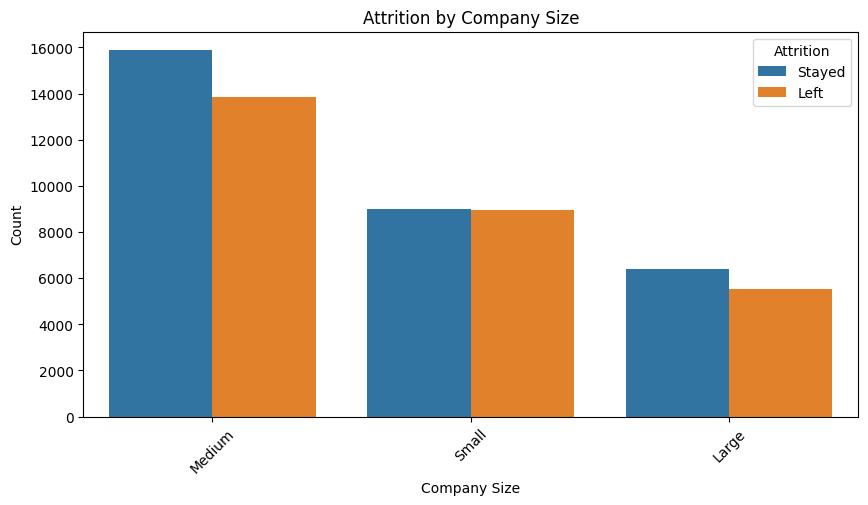

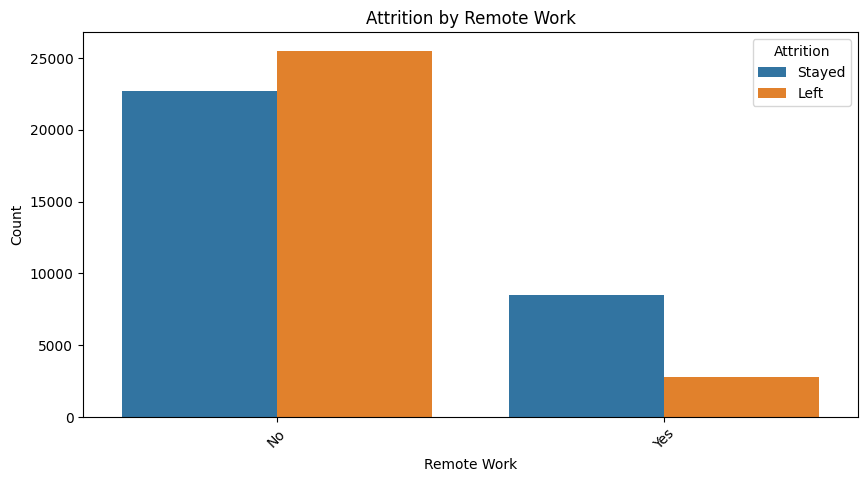

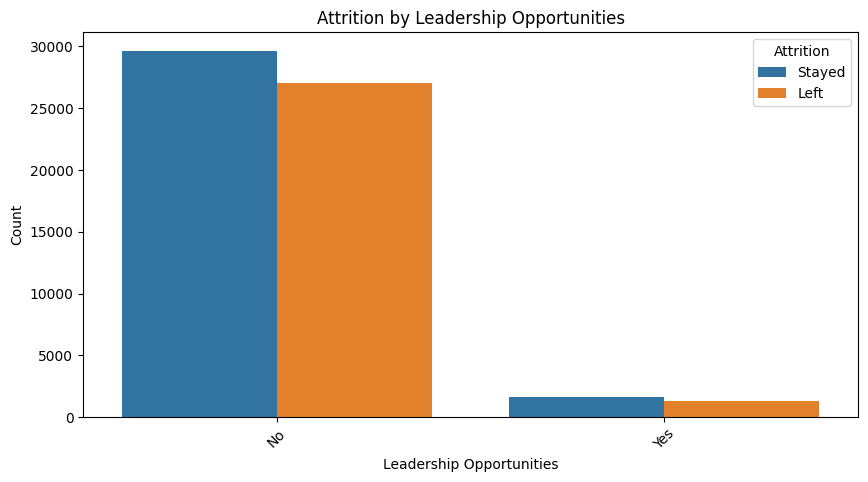

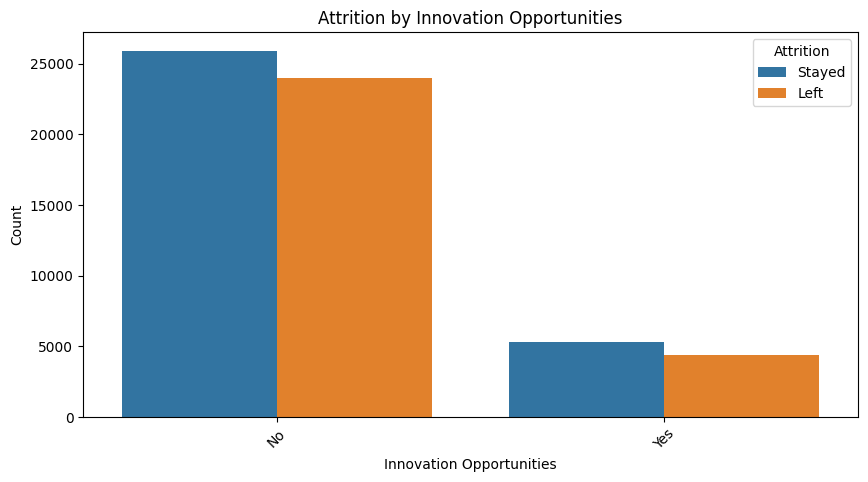

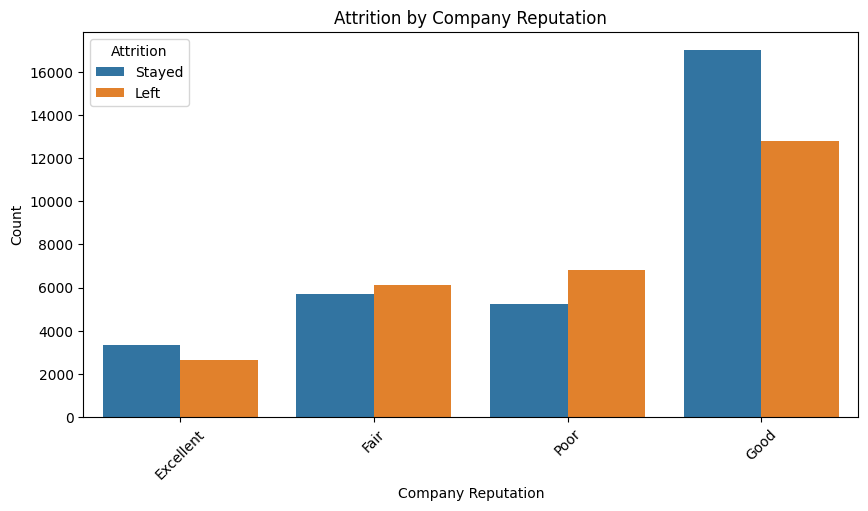

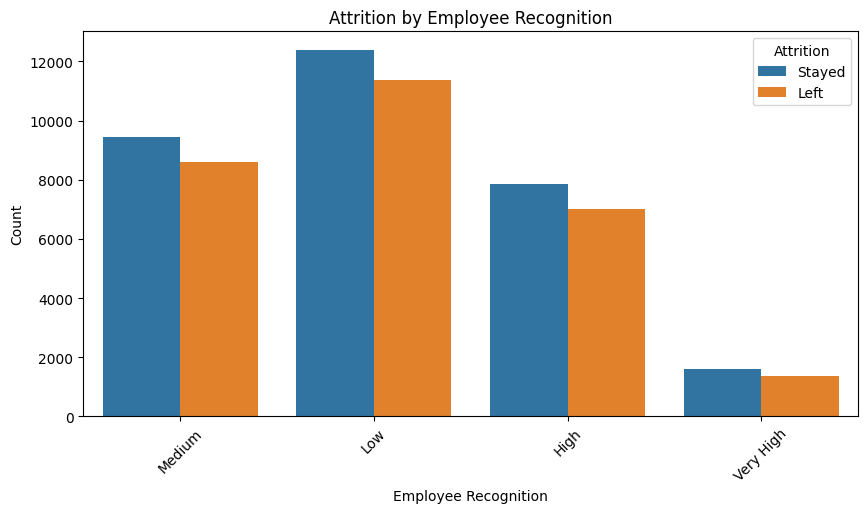

In [ ]:
# Attrition distribution across categorical features
for col in categorical_features:
    if X_train_full[col].nunique() <= 15:
        plt.figure(figsize=(10, 5))
        sns.countplot(data=train_df, x=col, hue=target_col)
        plt.title(f"{target_col} by {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()

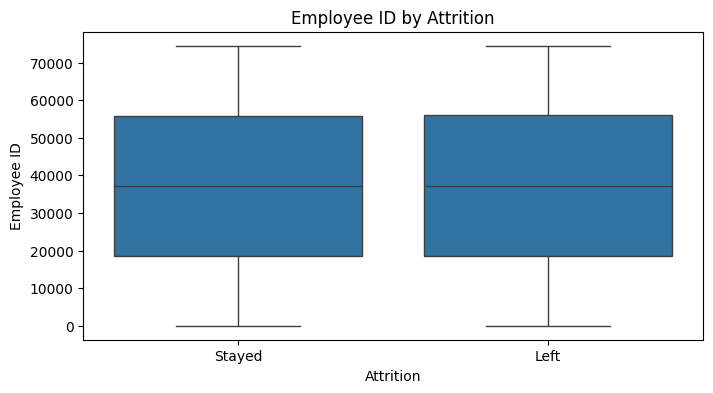

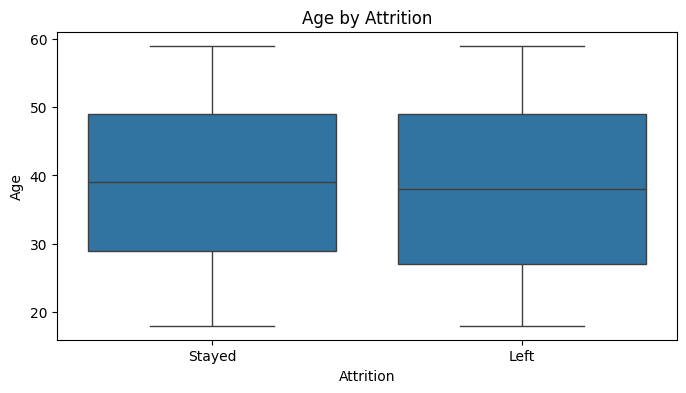

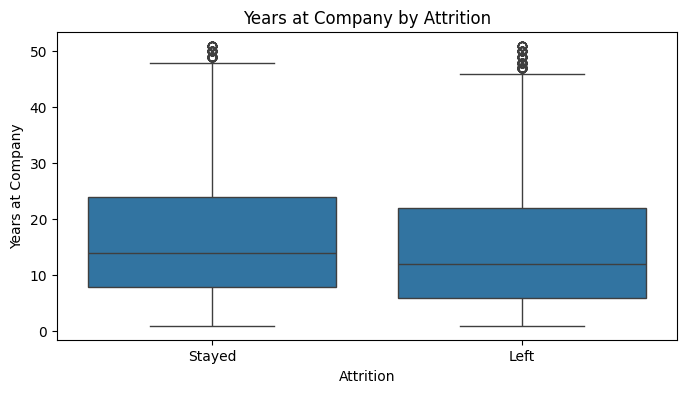

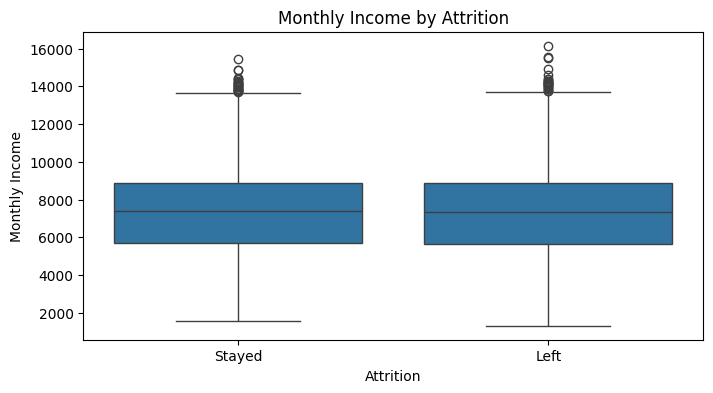

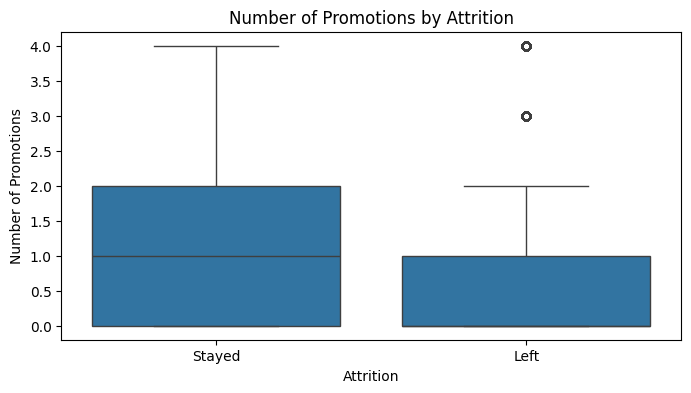

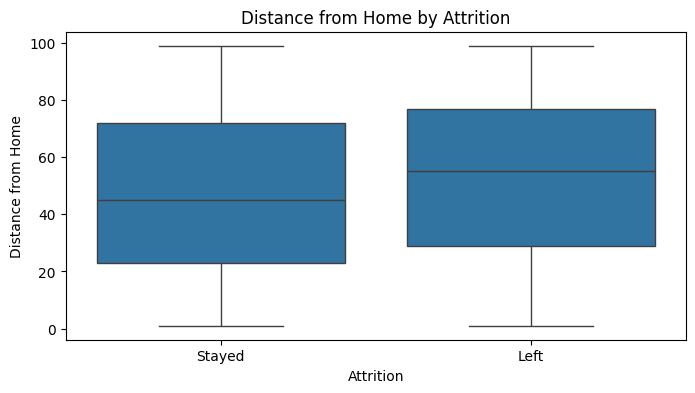

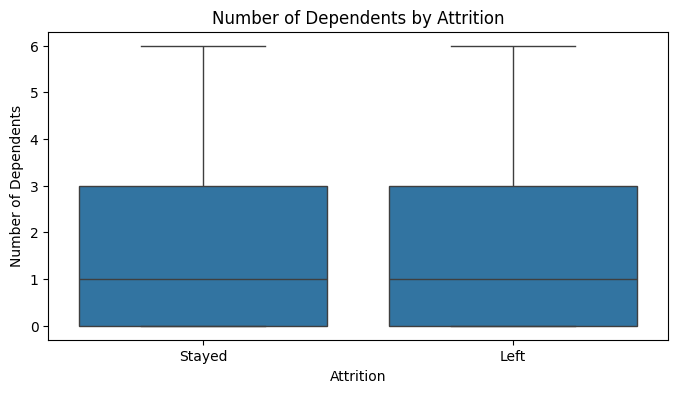

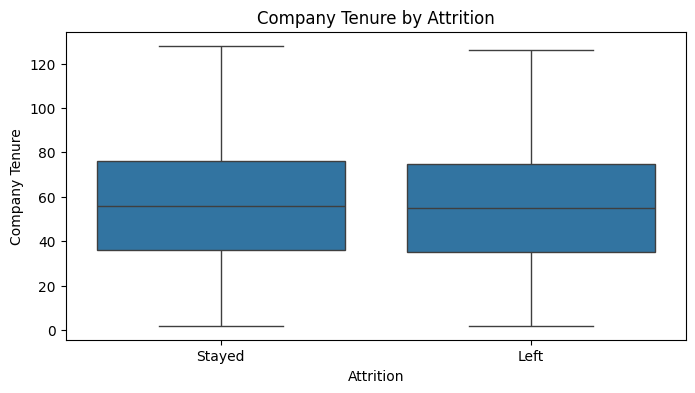

In [ ]:
# Numerical feature distributions by target class
for col in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=train_df, x=target_col, y=col)
    plt.title(f"{col} by {target_col}")
    plt.xlabel(target_col)
    plt.ylabel(col)
    plt.show()

**Preprocessing**

In [ ]:
# Import preprocessing libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("Preprocessing libraries imported successfully.")

Preprocessing libraries imported successfully.


In [ ]:
# Drop identifier column
id_col = "Employee ID"

X_train = X_train_full.drop(columns=[id_col]).copy()
X_test = X_test_full.drop(columns=[id_col]).copy()

print("Dropped identifier column:", id_col)
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

Dropped identifier column: Employee ID
X_train shape: (59598, 22)
X_test shape : (14900, 22)


In [ ]:
# Rebuild feature lists after dropping Employee ID
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Numerical features: ['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure']
Categorical features: ['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']
Number of numerical features: 7
Number of categorical features: 15


In [ ]:
# Encode target variable
target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train_full)
y_test = target_encoder.transform(y_test_full)

print("Target classes:", list(target_encoder.classes_))
print("Encoded mapping:")
for i, cls in enumerate(target_encoder.classes_):
    print(f"{cls} -> {i}")

Target classes: ['Left', 'Stayed']
Encoded mapping:
Left -> 0
Stayed -> 1


In [ ]:
# Create internal validation split from training data only
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training subset shape   :", X_train_sub.shape)
print("Validation subset shape :", X_val.shape)
print("Training target shape   :", y_train_sub.shape)
print("Validation target shape :", y_val.shape)

Training subset shape   : (47678, 22)
Validation subset shape : (11920, 22)
Training target shape   : (47678,)
Validation target shape : (11920,)


In [ ]:
# Check class balance after split
print("Train subset class distribution:")
print(pd.Series(y_train_sub).value_counts(normalize=True).sort_index() * 100)

print("\nValidation subset class distribution:")
print(pd.Series(y_val).value_counts(normalize=True).sort_index() * 100)

Train subset class distribution:
0    47.548135
1    52.451865
Name: proportion, dtype: float64

Validation subset class distribution:
0    47.550336
1    52.449664
Name: proportion, dtype: float64


In [ ]:
# Preprocessor for XGBoost and LightGBM
xgb_lgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features)
    ],
    remainder="drop"
)

print("XGBoost/LightGBM preprocessor created.")

XGBoost/LightGBM preprocessor created.


In [ ]:
# Fit and transform data for XGBoost and LightGBM
X_train_sub_xgb_lgb = xgb_lgb_preprocessor.fit_transform(X_train_sub)
X_val_xgb_lgb = xgb_lgb_preprocessor.transform(X_val)
X_test_xgb_lgb = xgb_lgb_preprocessor.transform(X_test)

print("X_train_sub_xgb_lgb shape:", X_train_sub_xgb_lgb.shape)
print("X_val_xgb_lgb shape      :", X_val_xgb_lgb.shape)
print("X_test_xgb_lgb shape     :", X_test_xgb_lgb.shape)

X_train_sub_xgb_lgb shape: (47678, 22)
X_val_xgb_lgb shape      : (11920, 22)
X_test_xgb_lgb shape     : (14900, 22)


In [ ]:
# Prepare raw copies for CatBoost
X_train_sub_cat = X_train_sub.copy()
X_val_cat = X_val.copy()
X_test_cat = X_test.copy()

catboost_cat_features = [X_train.columns.get_loc(col) for col in categorical_features]

print("Categorical feature indices for CatBoost:")
print(catboost_cat_features)
print("Number of CatBoost categorical features:", len(catboost_cat_features))

Categorical feature indices for CatBoost:
[1, 3, 5, 6, 7, 9, 11, 12, 14, 15, 17, 18, 19, 20, 21]
Number of CatBoost categorical features: 15


In [ ]:
# Create copies for TabNet preprocessing
X_train_sub_tabnet = X_train_sub.copy()
X_val_tabnet = X_val.copy()
X_test_tabnet = X_test.copy()

In [ ]:
# Ordinal encode categorical features for TabNet
tabnet_cat_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train_sub_tabnet[categorical_features] = tabnet_cat_encoder.fit_transform(X_train_sub_tabnet[categorical_features])
X_val_tabnet[categorical_features] = tabnet_cat_encoder.transform(X_val_tabnet[categorical_features])
X_test_tabnet[categorical_features] = tabnet_cat_encoder.transform(X_test_tabnet[categorical_features])

print("Categorical encoding completed for TabNet.")

Categorical encoding completed for TabNet.


In [ ]:
# Scale numerical features for TabNet
tabnet_scaler = StandardScaler()

X_train_sub_tabnet[numerical_features] = tabnet_scaler.fit_transform(X_train_sub_tabnet[numerical_features])
X_val_tabnet[numerical_features] = tabnet_scaler.transform(X_val_tabnet[numerical_features])
X_test_tabnet[numerical_features] = tabnet_scaler.transform(X_test_tabnet[numerical_features])

print("Numerical scaling completed for TabNet.")

Numerical scaling completed for TabNet.


In [ ]:
# Convert TabNet inputs to numpy arrays
X_train_sub_tabnet_np = X_train_sub_tabnet.values
X_val_tabnet_np = X_val_tabnet.values
X_test_tabnet_np = X_test_tabnet.values

print("X_train_sub_tabnet_np shape:", X_train_sub_tabnet_np.shape)
print("X_val_tabnet_np shape      :", X_val_tabnet_np.shape)
print("X_test_tabnet_np shape     :", X_test_tabnet_np.shape)

X_train_sub_tabnet_np shape: (47678, 22)
X_val_tabnet_np shape      : (11920, 22)
X_test_tabnet_np shape     : (14900, 22)


In [ ]:
# Build feature summary after preprocessing decisions
preprocessing_summary = pd.DataFrame({
    "feature": X_train.columns,
    "type": ["Numerical" if col in numerical_features else "Categorical" for col in X_train.columns],
    "used_for_xgb_lgb": True,
    "used_for_catboost": True,
    "used_for_tabnet": True
})

display(preprocessing_summary)

,feature,type,used_for_xgb_lgb,used_for_catboost,used_for_tabnet
0,Age,Numerical,True,True,True
1,Gender,Categorical,True,True,True
2,Years at Company,Numerical,True,True,True
3,Job Role,Categorical,True,True,True
4,Monthly Income,Numerical,True,True,True
5,Work-Life Balance,Categorical,True,True,True
6,Job Satisfaction,Categorical,True,True,True
7,Performance Rating,Categorical,True,True,True
8,Number of Promotions,Numerical,True,True,True
9,Overtime,Categorical,True,True,True


In [ ]:
print("Identifier dropped:", id_col)
print("Target classes:", list(target_encoder.classes_))
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Train subset shape:", X_train_sub.shape)
print("Validation subset shape:", X_val.shape)
print("Test shape:", X_test.shape)

Identifier dropped: Employee ID
Target classes: ['Left', 'Stayed']
Numerical features: 7
Categorical features: 15
Train subset shape: (47678, 22)
Validation subset shape: (11920, 22)
Test shape: (14900, 22)


**XGBoost Baseline**

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Train Time (s),Prediction Time (s)
0,XGBoost Baseline,0.753859,0.763083,0.769674,0.766364,0.8441,0.864211,20.687966,0.260455


Classification Report - XGBoost Baseline
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      5668
           1       0.76      0.77      0.77      6252

    accuracy                           0.75     11920
   macro avg       0.75      0.75      0.75     11920
weighted avg       0.75      0.75      0.75     11920



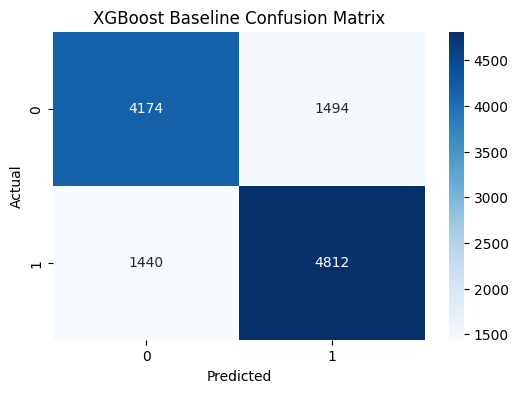

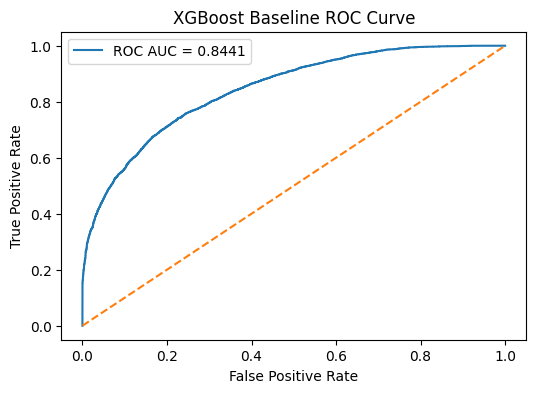

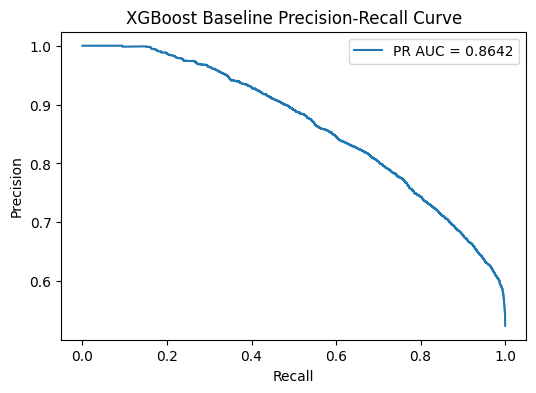

,Feature,Importance
15,Job Level,0.208211
14,Marital Status,0.178043
17,Remote Work,0.166935
9,Work-Life Balance,0.058942
7,Gender,0.045943
3,Number of Promotions,0.041717
13,Education Level,0.035168
20,Company Reputation,0.032677
5,Number of Dependents,0.028595
12,Overtime,0.023993


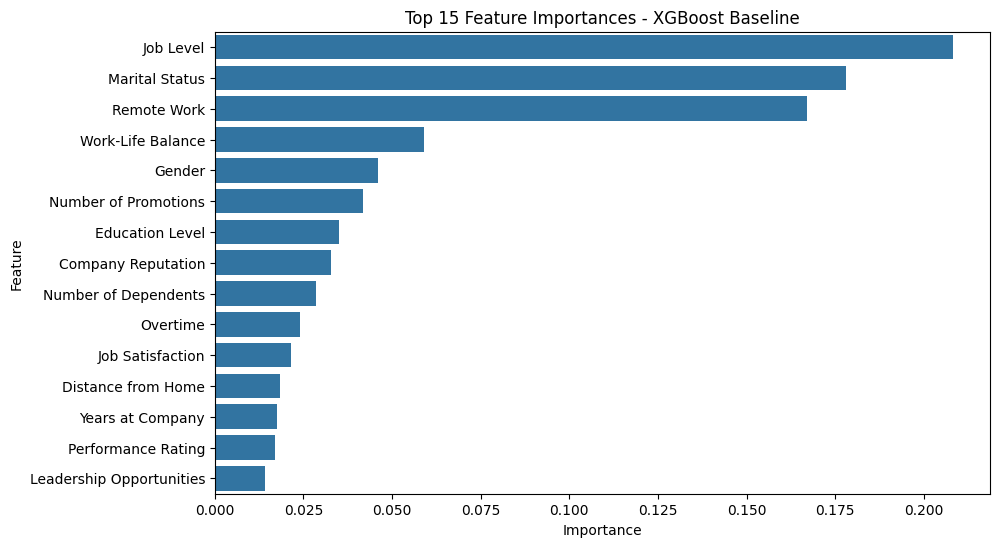

In [ ]:
# Import required libraries for XGBoost model training and evaluation
import time
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Create a function to store model evaluation results in a table
def evaluate_model(y_true, y_pred, y_prob, model_name, train_time, pred_time):
    results = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "PR AUC": average_precision_score(y_true, y_prob),
        "Train Time (s)": train_time,
        "Prediction Time (s)": pred_time
    }])
    return results

# Define the baseline XGBoost classifier
xgb_baseline = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

# Train the baseline XGBoost model and record training time
start_train = time.time()
xgb_baseline.fit(X_train_sub_xgb_lgb, y_train_sub)
xgb_baseline_train_time = time.time() - start_train

# Make predictions on the validation set and record prediction time
start_pred = time.time()
xgb_baseline_val_pred = xgb_baseline.predict(X_val_xgb_lgb)
xgb_baseline_val_prob = xgb_baseline.predict_proba(X_val_xgb_lgb)[:, 1]
xgb_baseline_pred_time = time.time() - start_pred

# Evaluate the baseline model on the validation set
xgb_baseline_results = evaluate_model(
    y_true=y_val,
    y_pred=xgb_baseline_val_pred,
    y_prob=xgb_baseline_val_prob,
    model_name="XGBoost Baseline",
    train_time=xgb_baseline_train_time,
    pred_time=xgb_baseline_pred_time
)

# Display the model evaluation results
display(xgb_baseline_results)

# Print the classification report
print("Classification Report - XGBoost Baseline")
print(classification_report(y_val, xgb_baseline_val_pred))

# Plot the confusion matrix
cm = confusion_matrix(y_val, xgb_baseline_val_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_val, xgb_baseline_val_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_val, xgb_baseline_val_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("XGBoost Baseline ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Plot the Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_val, xgb_baseline_val_prob)
plt.figure(figsize=(6, 4))
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {average_precision_score(y_val, xgb_baseline_val_prob):.4f}")
plt.title("XGBoost Baseline Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

# Create a feature importance table for the baseline XGBoost model
feature_names_xgb = numerical_features + categorical_features
importance_df_xgb = pd.DataFrame({
    "Feature": feature_names_xgb,
    "Importance": xgb_baseline.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Display top 15 most important features
display(importance_df_xgb.head(15))

# Plot top 15 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df_xgb.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances - XGBoost Baseline")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGBoost parameters:
{'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.8}


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Train Time (s),Prediction Time (s)
0,XGBoost Tuned,0.76099,0.767826,0.78023,0.773979,0.848642,0.868299,164.608097,0.157674


Classification Report - XGBoost Tuned
              precision    recall  f1-score   support

           0       0.75      0.74      0.75      5668
           1       0.77      0.78      0.77      6252

    accuracy                           0.76     11920
   macro avg       0.76      0.76      0.76     11920
weighted avg       0.76      0.76      0.76     11920



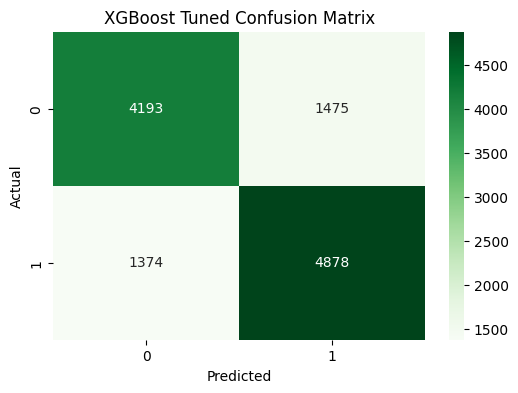

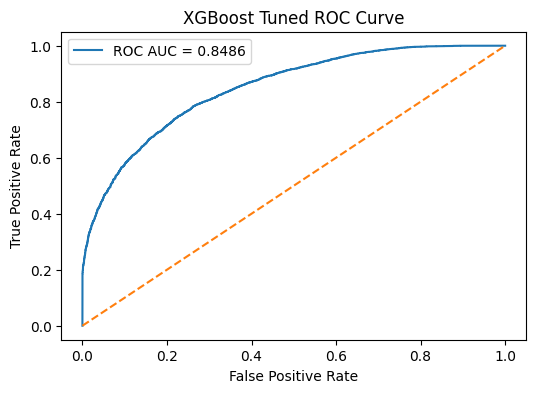

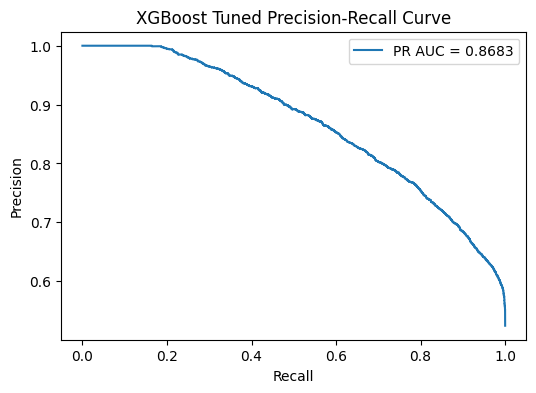

,Feature,Importance
15,Job Level,0.189089
14,Marital Status,0.163124
17,Remote Work,0.128083
9,Work-Life Balance,0.068457
3,Number of Promotions,0.062162
7,Gender,0.057651
13,Education Level,0.055456
5,Number of Dependents,0.049394
20,Company Reputation,0.037765
12,Overtime,0.030040


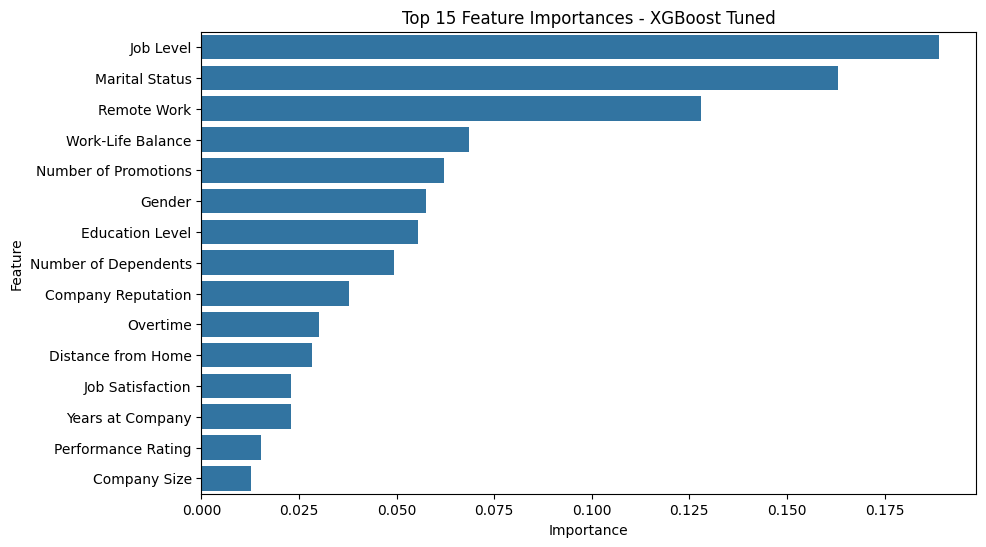

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Train Time (s),Prediction Time (s)
0,XGBoost Baseline,0.753859,0.763083,0.769674,0.766364,0.844100,0.864211,20.687966,0.260455
1,XGBoost Tuned,0.760990,0.767826,0.780230,0.773979,0.848642,0.868299,164.608097,0.157674


In [ ]:
# Import required libraries for XGBoost tuning and evaluation
import time
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import RandomizedSearchCV for hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Create a function to store model evaluation results in a table
def evaluate_model(y_true, y_pred, y_prob, model_name, train_time, pred_time):
    results = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "PR AUC": average_precision_score(y_true, y_prob),
        "Train Time (s)": train_time,
        "Prediction Time (s)": pred_time
    }])
    return results

# Define the hyperparameter search space for XGBoost tuning
xgb_param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 2, 5, 10]
}

# Define the base XGBoost model for tuning
xgb_model_for_tuning = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

# Set up RandomizedSearchCV to find the best XGBoost parameters
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_model_for_tuning,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="f1",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Run hyperparameter tuning and record training time
start_train = time.time()
xgb_random_search.fit(X_train_sub_xgb_lgb, y_train_sub)
xgb_tuned = xgb_random_search.best_estimator_
xgb_tuned_train_time = time.time() - start_train

# Print the best XGBoost parameters found during tuning
print("Best XGBoost parameters:")
print(xgb_random_search.best_params_)

# Make predictions on the validation set and record prediction time
start_pred = time.time()
xgb_tuned_val_pred = xgb_tuned.predict(X_val_xgb_lgb)
xgb_tuned_val_prob = xgb_tuned.predict_proba(X_val_xgb_lgb)[:, 1]
xgb_tuned_pred_time = time.time() - start_pred

# Evaluate the tuned XGBoost model on the validation set
xgb_tuned_results = evaluate_model(
    y_true=y_val,
    y_pred=xgb_tuned_val_pred,
    y_prob=xgb_tuned_val_prob,
    model_name="XGBoost Tuned",
    train_time=xgb_tuned_train_time,
    pred_time=xgb_tuned_pred_time
)

# Display the tuned model evaluation results
display(xgb_tuned_results)

# Print the classification report
print("Classification Report - XGBoost Tuned")
print(classification_report(y_val, xgb_tuned_val_pred))

# Plot the confusion matrix
cm = confusion_matrix(y_val, xgb_tuned_val_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("XGBoost Tuned Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_val, xgb_tuned_val_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_val, xgb_tuned_val_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("XGBoost Tuned ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Plot the Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_val, xgb_tuned_val_prob)
plt.figure(figsize=(6, 4))
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {average_precision_score(y_val, xgb_tuned_val_prob):.4f}")
plt.title("XGBoost Tuned Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

# Create a feature importance table for the tuned XGBoost model
feature_names_xgb = numerical_features + categorical_features
importance_df_xgb_tuned = pd.DataFrame({
    "Feature": feature_names_xgb,
    "Importance": xgb_tuned.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Display top 15 most important features
display(importance_df_xgb_tuned.head(15))

# Plot top 15 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df_xgb_tuned.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances - XGBoost Tuned")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Compare baseline and tuned XGBoost results
xgb_comparison = pd.concat([xgb_baseline_results, xgb_tuned_results], ignore_index=True)
display(xgb_comparison)

**LightGBM baseline**

[LightGBM] [Info] Number of positive: 25008, number of negative: 22670
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012334 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 640
[LightGBM] [Info] Number of data points in the train set: 47678, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524519 -> initscore=0.098153
[LightGBM] [Info] Start training from score 0.098153


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Train Time (s),Prediction Time (s)
0,LightGBM Baseline,0.75797,0.766503,0.774472,0.770467,0.845867,0.865693,1.7276,0.347747


Classification Report - LightGBM Baseline
              precision    recall  f1-score   support

           0       0.75      0.74      0.74      5668
           1       0.77      0.77      0.77      6252

    accuracy                           0.76     11920
   macro avg       0.76      0.76      0.76     11920
weighted avg       0.76      0.76      0.76     11920



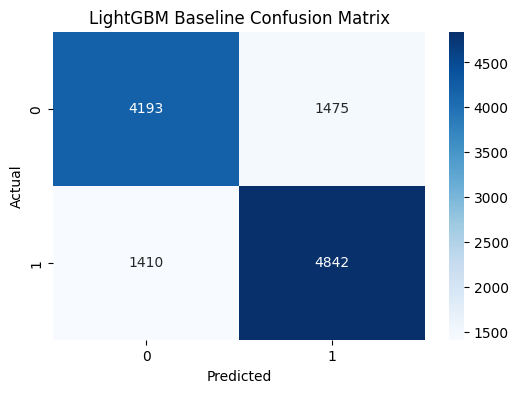

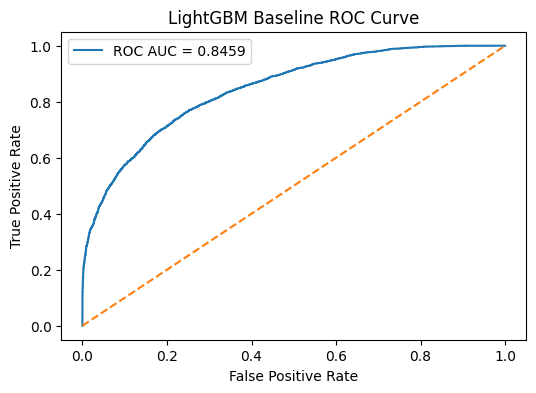

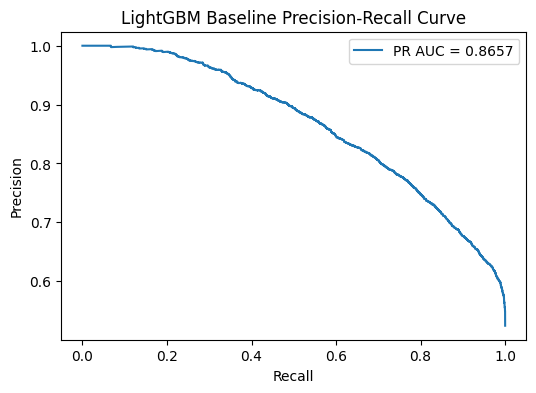

,Feature,Importance
6,Company Tenure,608
4,Distance from Home,602
2,Monthly Income,577
1,Years at Company,506
9,Work-Life Balance,456
0,Age,414
15,Job Level,314
5,Number of Dependents,281
3,Number of Promotions,268
13,Education Level,250


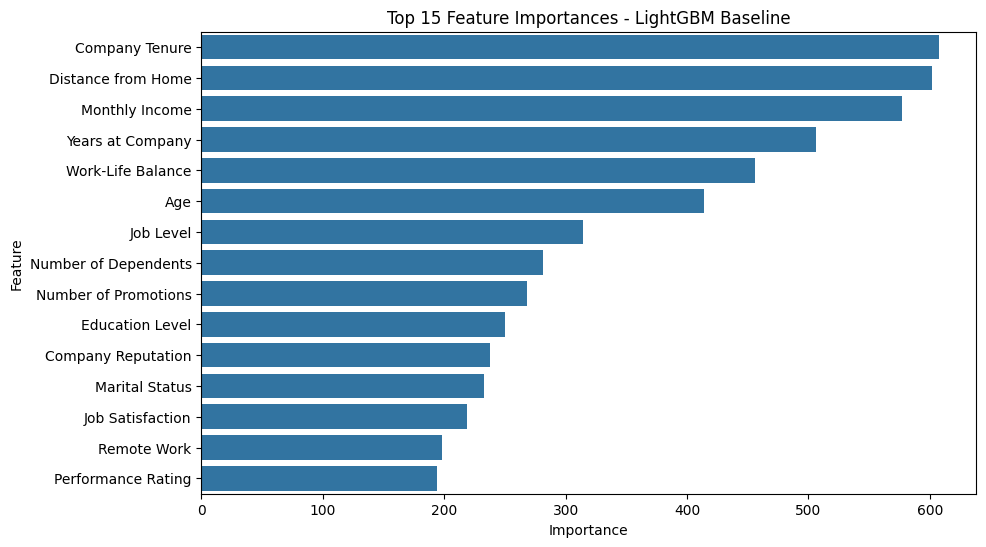

In [ ]:
# Install LightGBM library
!pip -q install lightgbm

# Import required libraries for LightGBM model training and evaluation
import time
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Create a function to store model evaluation results in a table
def evaluate_model(y_true, y_pred, y_prob, model_name, train_time, pred_time):
    results = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "PR AUC": average_precision_score(y_true, y_prob),
        "Train Time (s)": train_time,
        "Prediction Time (s)": pred_time
    }])
    return results

# Define the baseline LightGBM classifier
lgb_baseline = lgb.LGBMClassifier(
    objective="binary",
    random_state=42,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

# Train the baseline LightGBM model and record training time
start_train = time.time()
lgb_baseline.fit(X_train_sub_xgb_lgb, y_train_sub)
lgb_baseline_train_time = time.time() - start_train

# Make predictions on the validation set and record prediction time
start_pred = time.time()
lgb_baseline_val_pred = lgb_baseline.predict(X_val_xgb_lgb)
lgb_baseline_val_prob = lgb_baseline.predict_proba(X_val_xgb_lgb)[:, 1]
lgb_baseline_pred_time = time.time() - start_pred

# Evaluate the baseline model on the validation set
lgb_baseline_results = evaluate_model(
    y_true=y_val,
    y_pred=lgb_baseline_val_pred,
    y_prob=lgb_baseline_val_prob,
    model_name="LightGBM Baseline",
    train_time=lgb_baseline_train_time,
    pred_time=lgb_baseline_pred_time
)

# Display the model evaluation results
display(lgb_baseline_results)

# Print the classification report
print("Classification Report - LightGBM Baseline")
print(classification_report(y_val, lgb_baseline_val_pred))

# Plot the confusion matrix
cm = confusion_matrix(y_val, lgb_baseline_val_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("LightGBM Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_val, lgb_baseline_val_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_val, lgb_baseline_val_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("LightGBM Baseline ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Plot the Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_val, lgb_baseline_val_prob)
plt.figure(figsize=(6, 4))
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {average_precision_score(y_val, lgb_baseline_val_prob):.4f}")
plt.title("LightGBM Baseline Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

# Create a feature importance table for the baseline LightGBM model
feature_names_lgb = numerical_features + categorical_features
importance_df_lgb = pd.DataFrame({
    "Feature": feature_names_lgb,
    "Importance": lgb_baseline.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Display top 15 most important features
display(importance_df_lgb.head(15))

# Plot top 15 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df_lgb.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances - LightGBM Baseline")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 25008, number of negative: 22670
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006646 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 640
[LightGBM] [Info] Number of data points in the train set: 47678, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524519 -> initscore=0.098153
[LightGBM] [Info] Start training from score 0.098153
Best LightGBM parameters:
{'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 0, 'num_leaves': 15, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Train Time (s),Prediction Time (s)
0,LightGBM Tuned,0.760487,0.768793,0.777031,0.77289,0.847929,0.867487,143.745299,0.370631


Classification Report - LightGBM Tuned
              precision    recall  f1-score   support

           0       0.75      0.74      0.75      5668
           1       0.77      0.78      0.77      6252

    accuracy                           0.76     11920
   macro avg       0.76      0.76      0.76     11920
weighted avg       0.76      0.76      0.76     11920



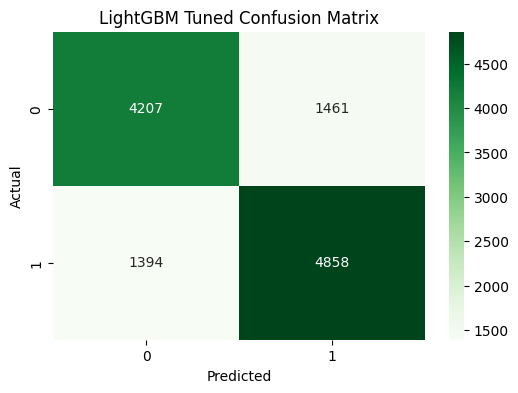

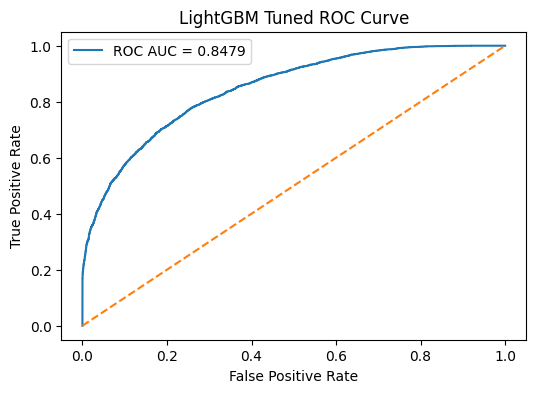

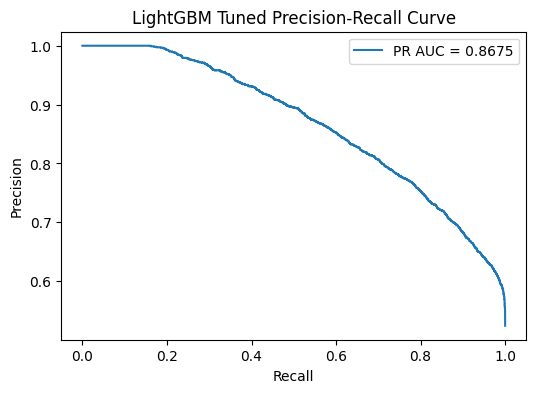

,Feature,Importance
15,Job Level,431
14,Marital Status,389
9,Work-Life Balance,345
4,Distance from Home,306
17,Remote Work,303
1,Years at Company,243
20,Company Reputation,243
0,Age,233
10,Job Satisfaction,209
2,Monthly Income,207


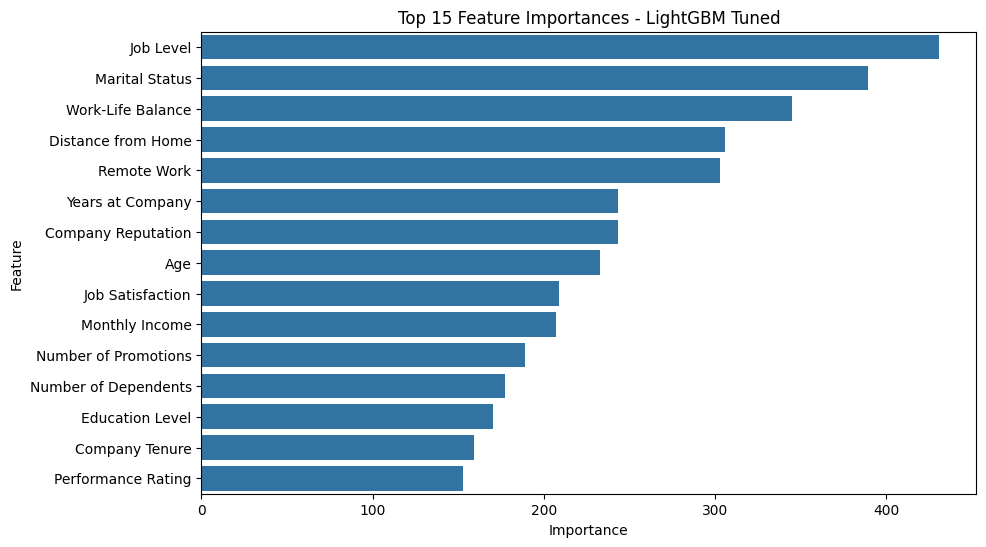

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Train Time (s),Prediction Time (s)
0,LightGBM Baseline,0.757970,0.766503,0.774472,0.770467,0.845867,0.865693,1.727600,0.347747
1,LightGBM Tuned,0.760487,0.768793,0.777031,0.772890,0.847929,0.867487,143.745299,0.370631


In [ ]:
# Import required libraries for LightGBM tuning and evaluation
import time
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import RandomizedSearchCV for hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Create a function to store model evaluation results in a table
def evaluate_model(y_true, y_pred, y_prob, model_name, train_time, pred_time):
    results = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "PR AUC": average_precision_score(y_true, y_prob),
        "Train Time (s)": train_time,
        "Prediction Time (s)": pred_time
    }])
    return results

# Define the hyperparameter search space for LightGBM tuning
lgb_param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [4, 5, 6, 8, 10, -1],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 50, 70, 100],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 2, 5, 10]
}

# Define the base LightGBM model for tuning
lgb_model_for_tuning = lgb.LGBMClassifier(
    objective="binary",
    random_state=42
)

# Set up RandomizedSearchCV to find the best LightGBM parameters
lgb_random_search = RandomizedSearchCV(
    estimator=lgb_model_for_tuning,
    param_distributions=lgb_param_grid,
    n_iter=20,
    scoring="f1",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Run hyperparameter tuning and record training time
start_train = time.time()
lgb_random_search.fit(X_train_sub_xgb_lgb, y_train_sub)
lgb_tuned = lgb_random_search.best_estimator_
lgb_tuned_train_time = time.time() - start_train

# Print the best LightGBM parameters found during tuning
print("Best LightGBM parameters:")
print(lgb_random_search.best_params_)

# Make predictions on the validation set and record prediction time
start_pred = time.time()
lgb_tuned_val_pred = lgb_tuned.predict(X_val_xgb_lgb)
lgb_tuned_val_prob = lgb_tuned.predict_proba(X_val_xgb_lgb)[:, 1]
lgb_tuned_pred_time = time.time() - start_pred

# Evaluate the tuned LightGBM model on the validation set
lgb_tuned_results = evaluate_model(
    y_true=y_val,
    y_pred=lgb_tuned_val_pred,
    y_prob=lgb_tuned_val_prob,
    model_name="LightGBM Tuned",
    train_time=lgb_tuned_train_time,
    pred_time=lgb_tuned_pred_time
)

# Display the tuned model evaluation results
display(lgb_tuned_results)

# Print the classification report
print("Classification Report - LightGBM Tuned")
print(classification_report(y_val, lgb_tuned_val_pred))

# Plot the confusion matrix
cm = confusion_matrix(y_val, lgb_tuned_val_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("LightGBM Tuned Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_val, lgb_tuned_val_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_val, lgb_tuned_val_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("LightGBM Tuned ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Plot the Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_val, lgb_tuned_val_prob)
plt.figure(figsize=(6, 4))
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {average_precision_score(y_val, lgb_tuned_val_prob):.4f}")
plt.title("LightGBM Tuned Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

# Create a feature importance table for the tuned LightGBM model
feature_names_lgb = numerical_features + categorical_features
importance_df_lgb_tuned = pd.DataFrame({
    "Feature": feature_names_lgb,
    "Importance": lgb_tuned.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Display top 15 most important features
display(importance_df_lgb_tuned.head(15))

# Plot top 15 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df_lgb_tuned.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances - LightGBM Tuned")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Compare baseline and tuned LightGBM results
lgb_comparison = pd.concat([lgb_baseline_results, lgb_tuned_results], ignore_index=True)
display(lgb_comparison)

**CatBoost baseline model**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.2 MB/s eta 0:00:00


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Train Time (s),Prediction Time (s)
0,CatBoost Baseline,0.759899,0.770767,0.771753,0.77126,0.849819,0.870202,22.546637,0.130676


Classification Report - CatBoost Baseline
              precision    recall  f1-score   support

           0       0.75      0.75      0.75      5668
           1       0.77      0.77      0.77      6252

    accuracy                           0.76     11920
   macro avg       0.76      0.76      0.76     11920
weighted avg       0.76      0.76      0.76     11920



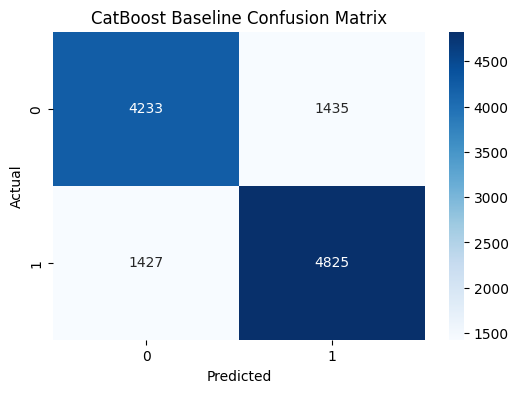

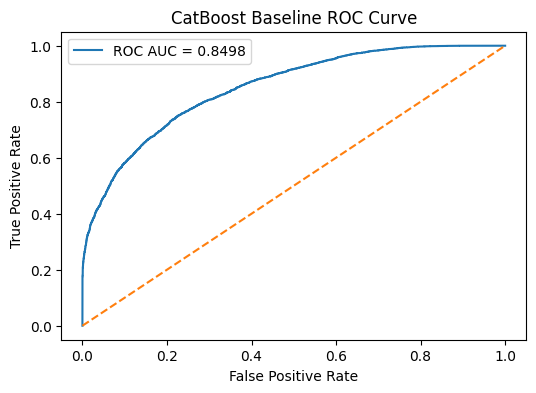

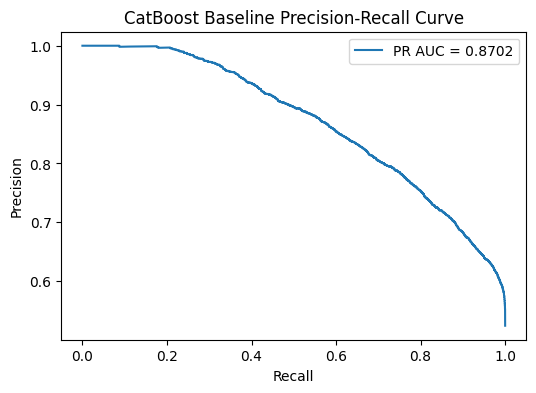

,Feature,Importance
14,Job Level,22.435981
12,Marital Status,17.599085
17,Remote Work,15.207569
5,Work-Life Balance,10.516332
8,Number of Promotions,5.067369
10,Distance from Home,3.694129
20,Company Reputation,3.596020
11,Education Level,3.535085
13,Number of Dependents,3.527269
1,Gender,2.987990


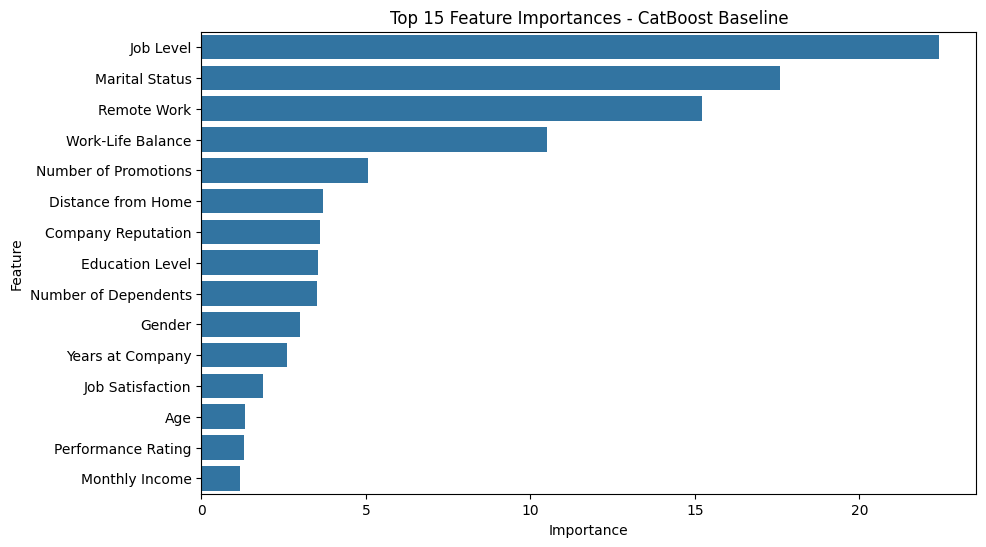

In [ ]:
# Install CatBoost library
!pip -q install catboost

# Import required libraries for CatBoost model training and evaluation
import time
import catboost as cb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Create a function to store model evaluation results in a table
def evaluate_model(y_true, y_pred, y_prob, model_name, train_time, pred_time):
    results = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "PR AUC": average_precision_score(y_true, y_prob),
        "Train Time (s)": train_time,
        "Prediction Time (s)": pred_time
    }])
    return results

# Define the baseline CatBoost classifier
cat_baseline = cb.CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    iterations=200,
    depth=6,
    learning_rate=0.1,
    verbose=0
)

# Train the baseline CatBoost model and record training time
start_train = time.time()
cat_baseline.fit(
    X_train_sub_cat,
    y_train_sub,
    cat_features=catboost_cat_features
)
cat_baseline_train_time = time.time() - start_train

# Make predictions on the validation set and record prediction time
start_pred = time.time()
cat_baseline_val_pred = cat_baseline.predict(X_val_cat)
cat_baseline_val_pred = pd.Series(cat_baseline_val_pred).astype(int).values
cat_baseline_val_prob = cat_baseline.predict_proba(X_val_cat)[:, 1]
cat_baseline_pred_time = time.time() - start_pred

# Evaluate the baseline model on the validation set
cat_baseline_results = evaluate_model(
    y_true=y_val,
    y_pred=cat_baseline_val_pred,
    y_prob=cat_baseline_val_prob,
    model_name="CatBoost Baseline",
    train_time=cat_baseline_train_time,
    pred_time=cat_baseline_pred_time
)

# Display the model evaluation results
display(cat_baseline_results)

# Print the classification report
print("Classification Report - CatBoost Baseline")
print(classification_report(y_val, cat_baseline_val_pred))

# Plot the confusion matrix
cm = confusion_matrix(y_val, cat_baseline_val_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CatBoost Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_val, cat_baseline_val_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_val, cat_baseline_val_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("CatBoost Baseline ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Plot the Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_val, cat_baseline_val_prob)
plt.figure(figsize=(6, 4))
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {average_precision_score(y_val, cat_baseline_val_prob):.4f}")
plt.title("CatBoost Baseline Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

# Create a feature importance table for the baseline CatBoost model
importance_df_cat = pd.DataFrame({
    "Feature": X_train_sub_cat.columns,
    "Importance": cat_baseline.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

# Display top 15 most important features
display(importance_df_cat.head(15))

# Plot top 15 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df_cat.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances - CatBoost Baseline")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CatBoost parameters:
{'learning_rate': 0.05, 'l2_leaf_reg': 9, 'iterations': 500, 'depth': 4, 'border_count': 64}


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Train Time (s),Prediction Time (s)
0,CatBoost Tuned,0.761997,0.771852,0.775432,0.773638,0.850434,0.870749,2814.011854,0.179716


Classification Report - CatBoost Tuned
              precision    recall  f1-score   support

           0       0.75      0.75      0.75      5668
           1       0.77      0.78      0.77      6252

    accuracy                           0.76     11920
   macro avg       0.76      0.76      0.76     11920
weighted avg       0.76      0.76      0.76     11920



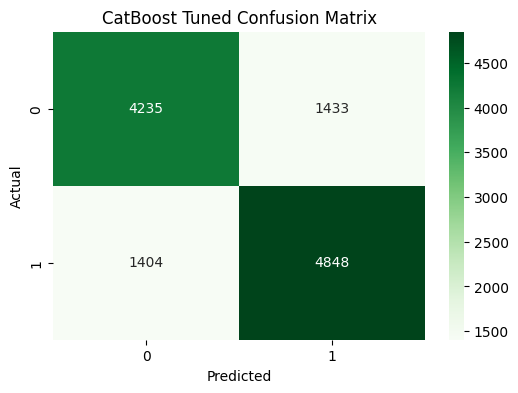

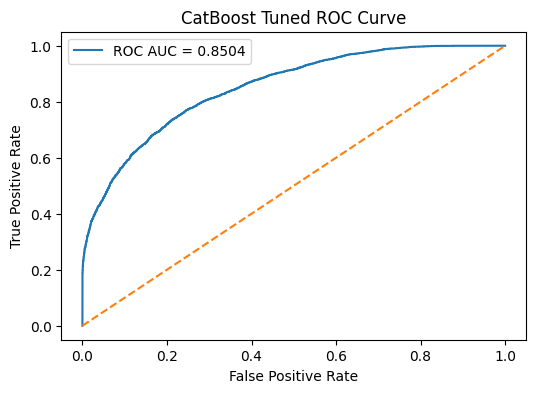

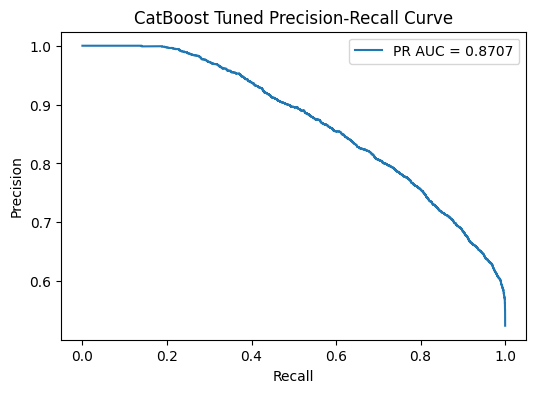

,Feature,Importance
14,Job Level,25.606783
12,Marital Status,18.970883
17,Remote Work,15.241120
5,Work-Life Balance,10.461273
8,Number of Promotions,5.463280
11,Education Level,3.627087
20,Company Reputation,3.571339
13,Number of Dependents,3.162226
10,Distance from Home,3.112411
1,Gender,2.916508


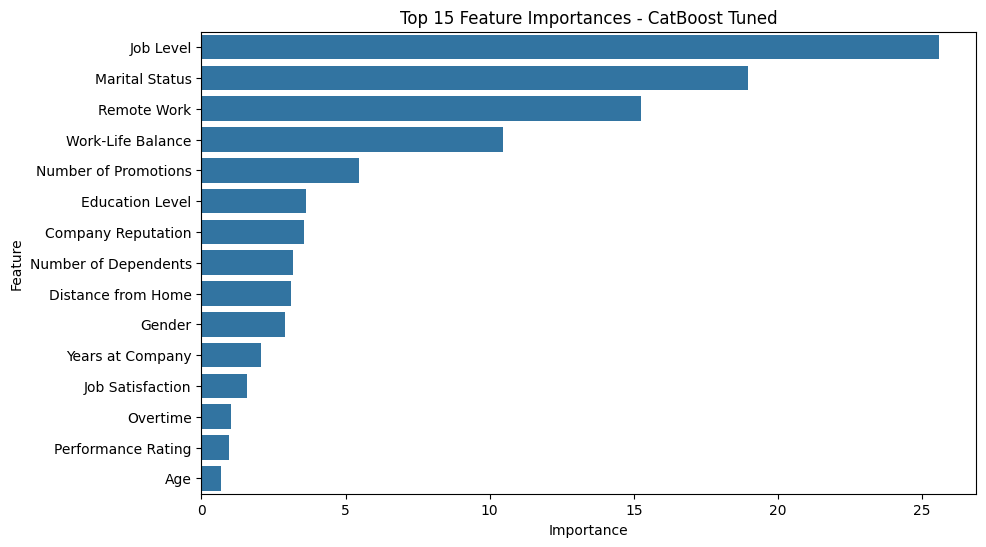

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Train Time (s),Prediction Time (s)
0,CatBoost Baseline,0.759899,0.770767,0.771753,0.771260,0.849819,0.870202,22.546637,0.130676
1,CatBoost Tuned,0.761997,0.771852,0.775432,0.773638,0.850434,0.870749,2814.011854,0.179716


In [ ]:
# Import required libraries for CatBoost tuning and evaluation
import time
import catboost as cb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import RandomizedSearchCV for hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Create a function to store model evaluation results in a table
def evaluate_model(y_true, y_pred, y_prob, model_name, train_time, pred_time):
    results = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "PR AUC": average_precision_score(y_true, y_prob),
        "Train Time (s)": train_time,
        "Prediction Time (s)": pred_time
    }])
    return results

# Define the hyperparameter search space for CatBoost tuning
cat_param_grid = {
    "iterations": [200, 300, 400, 500],
    "depth": [4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "border_count": [32, 64, 128, 254]
}

# Define the base CatBoost model for tuning
cat_model_for_tuning = cb.CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)

# Set up RandomizedSearchCV to find the best CatBoost parameters
cat_random_search = RandomizedSearchCV(
    estimator=cat_model_for_tuning,
    param_distributions=cat_param_grid,
    n_iter=20,
    scoring="f1",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Run hyperparameter tuning and record training time
start_train = time.time()
cat_random_search.fit(
    X_train_sub_cat,
    y_train_sub,
    cat_features=catboost_cat_features
)
cat_tuned = cat_random_search.best_estimator_
cat_tuned_train_time = time.time() - start_train

# Print the best CatBoost parameters found during tuning
print("Best CatBoost parameters:")
print(cat_random_search.best_params_)

# Make predictions on the validation set and record prediction time
start_pred = time.time()
cat_tuned_val_pred = cat_tuned.predict(X_val_cat)
cat_tuned_val_pred = pd.Series(cat_tuned_val_pred).astype(int).values
cat_tuned_val_prob = cat_tuned.predict_proba(X_val_cat)[:, 1]
cat_tuned_pred_time = time.time() - start_pred

# Evaluate the tuned CatBoost model on the validation set
cat_tuned_results = evaluate_model(
    y_true=y_val,
    y_pred=cat_tuned_val_pred,
    y_prob=cat_tuned_val_prob,
    model_name="CatBoost Tuned",
    train_time=cat_tuned_train_time,
    pred_time=cat_tuned_pred_time
)

# Display the tuned model evaluation results
display(cat_tuned_results)

# Print the classification report
print("Classification Report - CatBoost Tuned")
print(classification_report(y_val, cat_tuned_val_pred))

# Plot the confusion matrix
cm = confusion_matrix(y_val, cat_tuned_val_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("CatBoost Tuned Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_val, cat_tuned_val_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_val, cat_tuned_val_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("CatBoost Tuned ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Plot the Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_val, cat_tuned_val_prob)
plt.figure(figsize=(6, 4))
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {average_precision_score(y_val, cat_tuned_val_prob):.4f}")
plt.title("CatBoost Tuned Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

# Create a feature importance table for the tuned CatBoost model
importance_df_cat_tuned = pd.DataFrame({
    "Feature": X_train_sub_cat.columns,
    "Importance": cat_tuned.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

# Display top 15 most important features
display(importance_df_cat_tuned.head(15))

# Plot top 15 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df_cat_tuned.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances - CatBoost Tuned")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Compare baseline and tuned CatBoost results
cat_comparison = pd.concat([cat_baseline_results, cat_tuned_results], ignore_index=True)
display(cat_comparison)

**TabNet baseline model**

epoch 0  | loss: 0.69331 | validation_auc: 0.67438 |  0:00:04s
epoch 1  | loss: 0.58351 | validation_auc: 0.75182 |  0:00:09s
epoch 2  | loss: 0.57254 | validation_auc: 0.76666 |  0:00:15s
epoch 3  | loss: 0.56629 | validation_auc: 0.77323 |  0:00:20s
epoch 4  | loss: 0.56627 | validation_auc: 0.78371 |  0:00:28s
epoch 5  | loss: 0.55969 | validation_auc: 0.78259 |  0:00:33s
epoch 6  | loss: 0.55616 | validation_auc: 0.78884 |  0:00:39s
epoch 7  | loss: 0.55125 | validation_auc: 0.78656 |  0:00:45s
epoch 8  | loss: 0.55145 | validation_auc: 0.79173 |  0:00:50s
epoch 9  | loss: 0.54502 | validation_auc: 0.79679 |  0:00:56s
epoch 10 | loss: 0.53791 | validation_auc: 0.79989 |  0:01:01s
epoch 11 | loss: 0.5348  | validation_auc: 0.80851 |  0:01:06s
epoch 12 | loss: 0.5288  | validation_auc: 0.80938 |  0:01:12s
epoch 13 | loss: 0.52862 | validation_auc: 0.80544 |  0:01:16s
epoch 14 | loss: 0.52883 | validation_auc: 0.81002 |  0:01:21s
epoch 15 | loss: 0.52636 | validation_auc: 0.81249 |  0

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Train Time (s),Prediction Time (s)
0,TabNet Baseline,0.750252,0.771874,0.743602,0.757475,0.836844,0.853836,252.545374,0.640065


Classification Report - TabNet Baseline
              precision    recall  f1-score   support

           0       0.73      0.76      0.74      5668
           1       0.77      0.74      0.76      6252

    accuracy                           0.75     11920
   macro avg       0.75      0.75      0.75     11920
weighted avg       0.75      0.75      0.75     11920



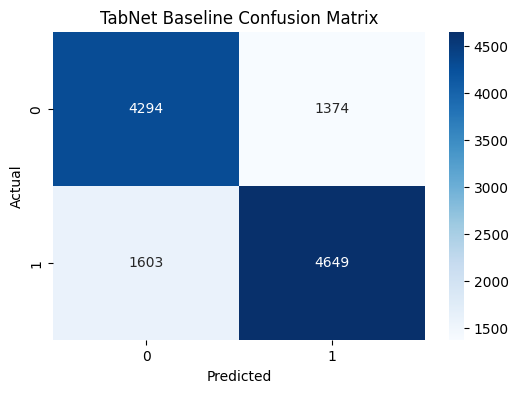

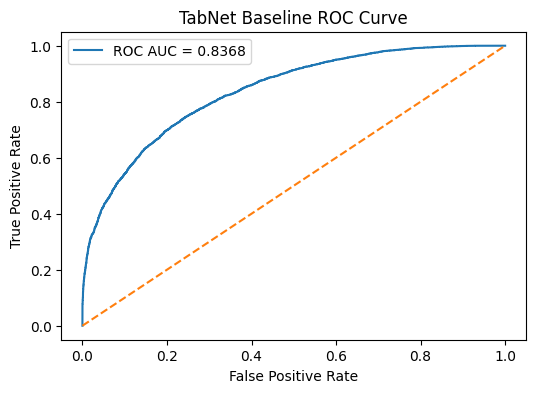

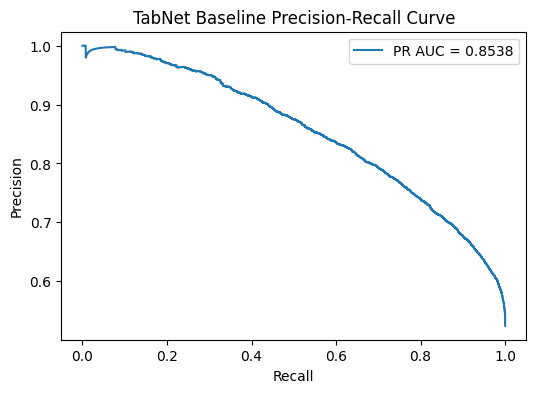

,Feature,Importance
5,Work-Life Balance,0.262110
12,Marital Status,0.158218
17,Remote Work,0.102577
14,Job Level,0.098743
10,Distance from Home,0.074379
6,Job Satisfaction,0.066564
20,Company Reputation,0.063229
1,Gender,0.060944
11,Education Level,0.057304
8,Number of Promotions,0.022071


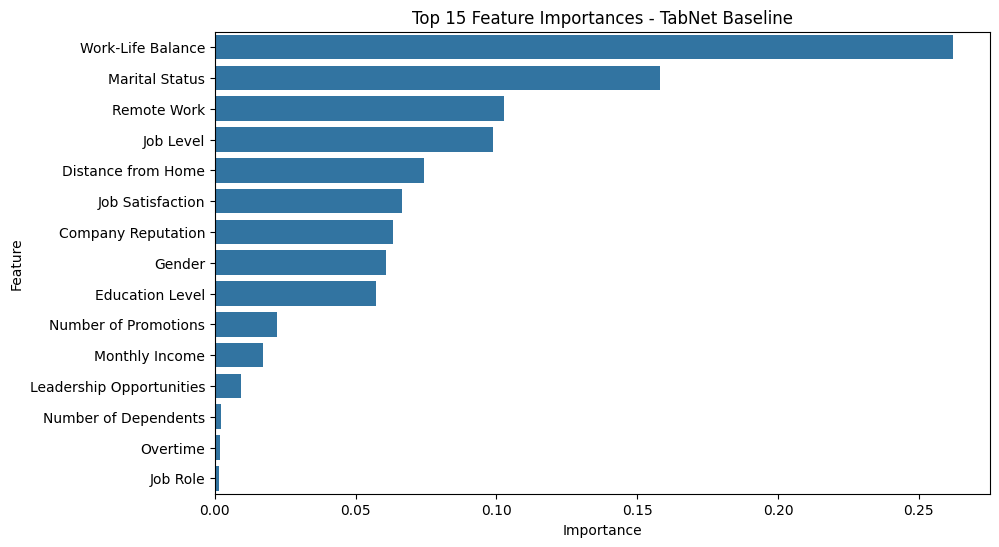

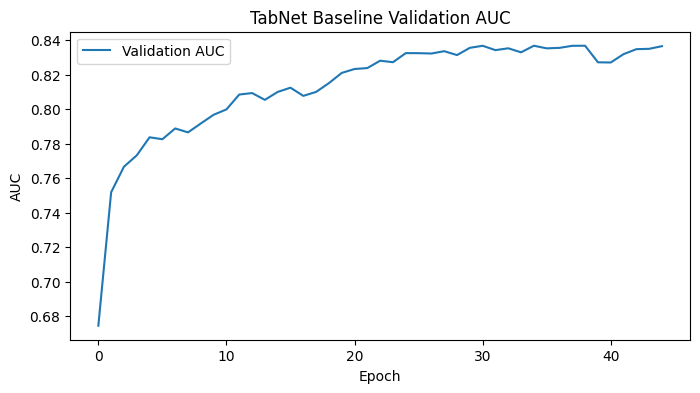

In [ ]:
# Install TabNet library
!pip -q install pytorch-tabnet

# Import required libraries for TabNet model training and evaluation
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import TabNet classifier
from pytorch_tabnet.tab_model import TabNetClassifier

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Create a function to store model evaluation results in a table
def evaluate_model(y_true, y_pred, y_prob, model_name, train_time, pred_time):
    results = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "PR AUC": average_precision_score(y_true, y_prob),
        "Train Time (s)": train_time,
        "Prediction Time (s)": pred_time
    }])
    return results

# Define the baseline TabNet classifier
tabnet_baseline = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_params=dict(lr=2e-2),
    mask_type="entmax",
    scheduler_params={"step_size": 20, "gamma": 0.9},
    scheduler_fn=None,
    seed=42,
    verbose=1
)

# Train the baseline TabNet model and record training time
start_train = time.time()
tabnet_baseline.fit(
    X_train=X_train_sub_tabnet_np,
    y_train=y_train_sub,
    eval_set=[(X_val_tabnet_np, y_val)],
    eval_name=["validation"],
    eval_metric=["auc"],
    max_epochs=50,
    patience=10,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)
tabnet_baseline_train_time = time.time() - start_train

# Make predictions on the validation set and record prediction time
start_pred = time.time()
tabnet_baseline_val_prob = tabnet_baseline.predict_proba(X_val_tabnet_np)[:, 1]
tabnet_baseline_val_pred = (tabnet_baseline_val_prob >= 0.5).astype(int)
tabnet_baseline_pred_time = time.time() - start_pred

# Evaluate the baseline model on the validation set
tabnet_baseline_results = evaluate_model(
    y_true=y_val,
    y_pred=tabnet_baseline_val_pred,
    y_prob=tabnet_baseline_val_prob,
    model_name="TabNet Baseline",
    train_time=tabnet_baseline_train_time,
    pred_time=tabnet_baseline_pred_time
)

# Display the model evaluation results
display(tabnet_baseline_results)

# Print the classification report
print("Classification Report - TabNet Baseline")
print(classification_report(y_val, tabnet_baseline_val_pred))

# Plot the confusion matrix
cm = confusion_matrix(y_val, tabnet_baseline_val_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("TabNet Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_val, tabnet_baseline_val_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_val, tabnet_baseline_val_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("TabNet Baseline ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Plot the Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_val, tabnet_baseline_val_prob)
plt.figure(figsize=(6, 4))
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {average_precision_score(y_val, tabnet_baseline_val_prob):.4f}")
plt.title("TabNet Baseline Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

# Create a feature importance table for the baseline TabNet model
tabnet_baseline_importance = pd.DataFrame({
    "Feature": X_train_sub_tabnet.columns,
    "Importance": tabnet_baseline.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Display top 15 most important features
display(tabnet_baseline_importance.head(15))

# Plot top 15 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=tabnet_baseline_importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances - TabNet Baseline")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Plot validation AUC history if available
if hasattr(tabnet_baseline, "history"):
    try:
        val_auc_history = tabnet_baseline.history["validation_auc"]
        plt.figure(figsize=(8, 4))
        plt.plot(val_auc_history, label="Validation AUC")
        plt.title("TabNet Baseline Validation AUC")
        plt.xlabel("Epoch")
        plt.ylabel("AUC")
        plt.legend()
        plt.show()
    except KeyError as e:
        print(f"KeyError encountered: {e}")
        print("Available keys in tabnet_baseline.history:")
        if hasattr(tabnet_baseline.history, 'keys'):
            print(tabnet_baseline.history.keys())
        else:
            print("The history object does not have a 'keys()' method.")
else:
    print("tabnet_baseline does not have a 'history' attribute.")


**TabNet tuned model**

In [ ]:
# Import required libraries for TabNet tuning and evaluation
import time
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import TabNet classifier
from pytorch_tabnet.tab_model import TabNetClassifier

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Create a function to store model evaluation results in a table
def evaluate_model(y_true, y_pred, y_prob, model_name, train_time, pred_time):
    results = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "PR AUC": average_precision_score(y_true, y_prob),
        "Train Time (s)": train_time,
        "Prediction Time (s)": pred_time
    }])
    return results

# Define the hyperparameter search space for TabNet tuning
tabnet_param_grid = {
    "n_d": [16, 24, 32],
    "n_a": [16, 24, 32],
    "n_steps": [4, 5, 6],
    "gamma": [1.2, 1.5, 1.8],
    "lambda_sparse": [1e-4, 1e-3],
    "lr": [1e-2, 2e-2],
    "batch_size": [512, 1024]
}

# Generate all possible parameter combinations
param_combinations = list(itertools.product(
    tabnet_param_grid["n_d"],
    tabnet_param_grid["n_a"],
    tabnet_param_grid["n_steps"],
    tabnet_param_grid["gamma"],
    tabnet_param_grid["lambda_sparse"],
    tabnet_param_grid["lr"],
    tabnet_param_grid["batch_size"]
))

# Randomly select 10 parameter combinations for tuning
np.random.seed(42)
selected_combinations = [param_combinations[i] for i in np.random.choice(len(param_combinations), size=10, replace=False)]

# Initialize variables to store the best model and results
best_tabnet = None
best_tabnet_auc = -1
best_tabnet_params = None
tabnet_tuning_results = []

# Start overall tuning timer
overall_start = time.time()

# Train TabNet model for each selected parameter combination
for idx, params in enumerate(selected_combinations, 1):
    n_d, n_a, n_steps, gamma, lambda_sparse, lr, batch_size = params

    # Print the current training configuration
    print(f"Training configuration {idx}/10")
    print({
        "n_d": n_d,
        "n_a": n_a,
        "n_steps": n_steps,
        "gamma": gamma,
        "lambda_sparse": lambda_sparse,
        "lr": lr,
        "batch_size": batch_size
    })

    # Create TabNet model with current parameters
    model = TabNetClassifier(
        n_d=n_d,
        n_a=n_a,
        n_steps=n_steps,
        gamma=gamma,
        lambda_sparse=lambda_sparse,
        optimizer_params=dict(lr=lr),
        mask_type="entmax",
        seed=42,
        verbose=0
    )

    # Train the model on training data and validate on validation data
    model.fit(
        X_train=X_train_sub_tabnet_np,
        y_train=y_train_sub,
        eval_set=[(X_val_tabnet_np, y_val)],
        eval_name=["validation"],
        eval_metric=["auc"],
        max_epochs=50,
        patience=10,
        batch_size=batch_size,
        virtual_batch_size=128,
        num_workers=0,
        drop_last=False
    )

    # Predict probabilities on the validation set
    val_prob = model.predict_proba(X_val_tabnet_np)[:, 1]

    # Calculate validation ROC AUC score
    val_auc = roc_auc_score(y_val, val_prob)

    # Store tuning results for current configuration
    tabnet_tuning_results.append({
        "n_d": n_d,
        "n_a": n_a,
        "n_steps": n_steps,
        "gamma": gamma,
        "lambda_sparse": lambda_sparse,
        "lr": lr,
        "batch_size": batch_size,
        "val_auc": val_auc
    })

    # Update the best model if current model performs better
    if val_auc > best_tabnet_auc:
        best_tabnet_auc = val_auc
        best_tabnet = model
        best_tabnet_params = {
            "n_d": n_d,
            "n_a": n_a,
            "n_steps": n_steps,
            "gamma": gamma,
            "lambda_sparse": lambda_sparse,
            "lr": lr,
            "batch_size": batch_size
        }

# Record total tuning time
tabnet_tuned_train_time = time.time() - overall_start

# Print the best TabNet parameters and best validation ROC AUC
print("Best TabNet parameters:")
print(best_tabnet_params)
print("Best validation ROC AUC:", round(best_tabnet_auc, 6))

# Create and display a table of all TabNet tuning results
tabnet_tuning_results_df = pd.DataFrame(tabnet_tuning_results).sort_values(by="val_auc", ascending=False)
display(tabnet_tuning_results_df)

Training configuration 1/10
{'n_d': 32, 'n_a': 32, 'n_steps': 6, 'gamma': 1.5, 'lambda_sparse': 0.0001, 'lr': 0.02, 'batch_size': 1024}
Stop training because you reached max_epochs = 50 with best_epoch = 49 and best_validation_auc = 0.83495
Training configuration 2/10
{'n_d': 24, 'n_a': 16, 'n_steps': 4, 'gamma': 1.2, 'lambda_sparse': 0.001, 'lr': 0.01, 'batch_size': 512}

Early stopping occurred at epoch 30 with best_epoch = 20 and best_validation_auc = 0.83556
Training configuration 3/10
{'n_d': 32, 'n_a': 32, 'n_steps': 4, 'gamma': 1.8, 'lambda_sparse': 0.0001, 'lr': 0.01, 'batch_size': 1024}

Early stopping occurred at epoch 46 with best_epoch = 36 and best_validation_auc = 0.83541
Training configuration 4/10
{'n_d': 24, 'n_a': 32, 'n_steps': 6, 'gamma': 1.8, 'lambda_sparse': 0.001, 'lr': 0.01, 'batch_size': 1024}
Stop training because you reached max_epochs = 50 with best_epoch = 48 and best_validation_auc = 0.82471
Training configuration 5/10
{'n_d': 16, 'n_a': 24, 'n_steps': 4, 

,n_d,n_a,n_steps,gamma,lambda_sparse,lr,batch_size,val_auc
8,24,16,4,1.5,0.0010,0.02,1024,0.840060
5,32,16,4,1.8,0.0001,0.01,512,0.839014
4,16,24,4,1.2,0.0001,0.01,512,0.838251
1,24,16,4,1.2,0.0010,0.01,512,0.835561
2,32,32,4,1.8,0.0001,0.01,1024,0.835408
0,32,32,6,1.5,0.0001,0.02,1024,0.834950
6,16,32,5,1.5,0.0010,0.01,1024,0.829436
9,24,16,6,1.5,0.0010,0.01,1024,0.825349
3,24,32,6,1.8,0.0010,0.01,1024,0.824714
7,16,24,6,1.5,0.0001,0.02,1024,0.824390


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Train Time (s),Prediction Time (s)
0,TabNet Tuned,0.752349,0.761159,0.769194,0.765155,0.84006,0.858905,3102.754004,0.763038


Classification Report - TabNet Tuned
              precision    recall  f1-score   support

           0       0.74      0.73      0.74      5668
           1       0.76      0.77      0.77      6252

    accuracy                           0.75     11920
   macro avg       0.75      0.75      0.75     11920
weighted avg       0.75      0.75      0.75     11920



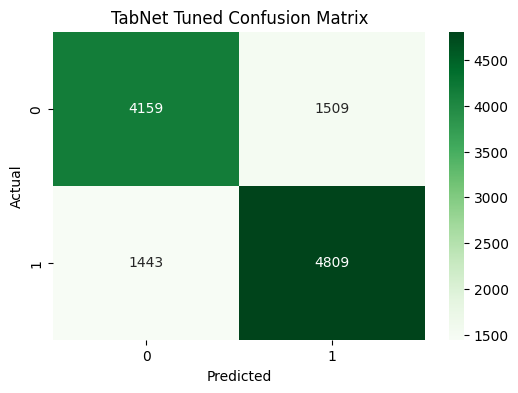

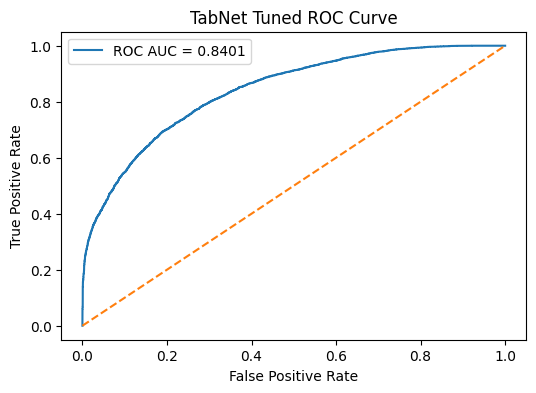

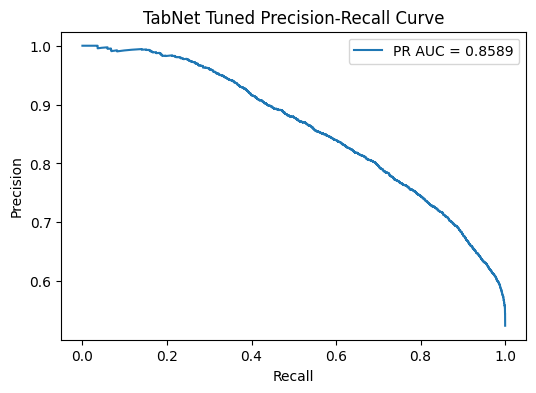

,Feature,Importance
17,Remote Work,0.141554
14,Job Level,0.129935
5,Work-Life Balance,0.117798
13,Number of Dependents,0.115209
0,Age,0.102782
12,Marital Status,0.087088
20,Company Reputation,0.084844
11,Education Level,0.072726
10,Distance from Home,0.061522
8,Number of Promotions,0.060690


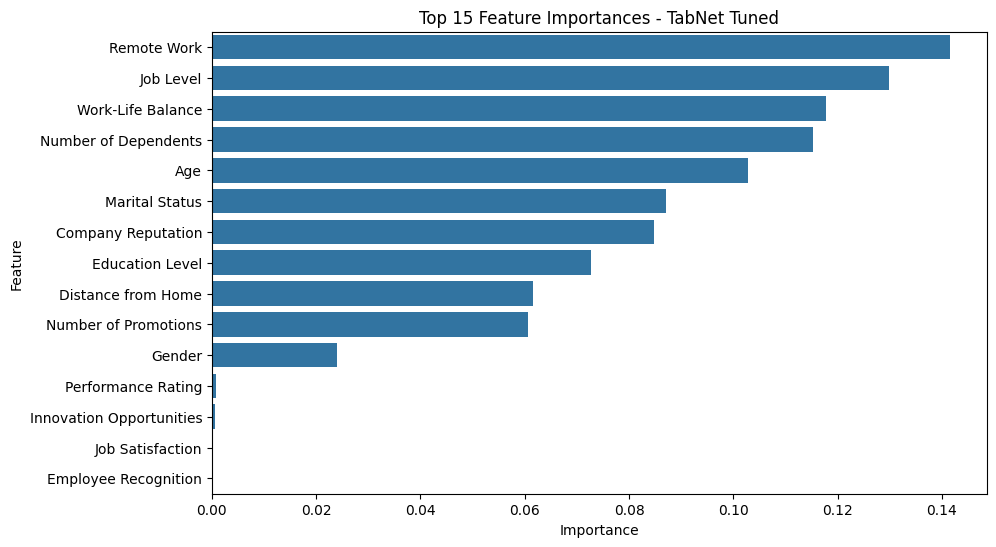

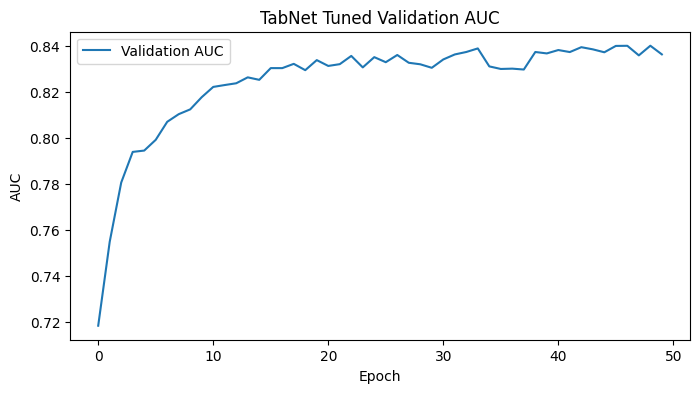

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Train Time (s),Prediction Time (s)
0,TabNet Baseline,0.750252,0.771874,0.743602,0.757475,0.836844,0.853836,252.545374,0.640065
1,TabNet Tuned,0.752349,0.761159,0.769194,0.765155,0.840060,0.858905,3102.754004,0.763038


In [ ]:
# Record prediction time for the tuned TabNet model
start_pred = time.time()
tabnet_tuned_val_prob = best_tabnet.predict_proba(X_val_tabnet_np)[:, 1]
tabnet_tuned_val_pred = (tabnet_tuned_val_prob >= 0.5).astype(int)
tabnet_tuned_pred_time = time.time() - start_pred

# Evaluate the tuned TabNet model on the validation set
tabnet_tuned_results = evaluate_model(
    y_true=y_val,
    y_pred=tabnet_tuned_val_pred,
    y_prob=tabnet_tuned_val_prob,
    model_name="TabNet Tuned",
    train_time=tabnet_tuned_train_time,
    pred_time=tabnet_tuned_pred_time
)

# Display the tuned model evaluation results
display(tabnet_tuned_results)

# Print the classification report
print("Classification Report - TabNet Tuned")
print(classification_report(y_val, tabnet_tuned_val_pred))

# Plot the confusion matrix
cm = confusion_matrix(y_val, tabnet_tuned_val_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("TabNet Tuned Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_val, tabnet_tuned_val_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_val, tabnet_tuned_val_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("TabNet Tuned ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Plot the Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_val, tabnet_tuned_val_prob)
plt.figure(figsize=(6, 4))
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {average_precision_score(y_val, tabnet_tuned_val_prob):.4f}")
plt.title("TabNet Tuned Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

# Create a feature importance table for the tuned TabNet model
tabnet_tuned_importance = pd.DataFrame({
    "Feature": X_train_sub_tabnet.columns,
    "Importance": best_tabnet.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Display top 15 most important features
display(tabnet_tuned_importance.head(15))

# Plot top 15 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=tabnet_tuned_importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances - TabNet Tuned")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Plot validation AUC history for the tuned TabNet model if available
if hasattr(tabnet_baseline, "history"):
    try:
        val_auc_history = best_tabnet.history["validation_auc"]
        plt.figure(figsize=(8, 4))
        plt.plot(val_auc_history, label="Validation AUC")
        plt.title("TabNet Tuned Validation AUC")
        plt.xlabel("Epoch")
        plt.ylabel("AUC")
        plt.legend()
        plt.show()
    except KeyError as e:
        print(f"KeyError encountered: {e}")
        print("Available keys in tabnet_baseline.history:")
        if hasattr(tabnet_baseline.history, 'keys'):
            print(tabnet_baseline.history.keys())
        else:
            print("The history object does not have a 'keys()' method.")
else:
    print("tabnet_baseline does not have a 'history' attribute.")

# Compare baseline and tuned TabNet results
tabnet_comparison = pd.concat([tabnet_baseline_results, tabnet_tuned_results], ignore_index=True)
display(tabnet_comparison)


**FINAL MODEL COMPARISON + BEST MODEL SELECTION**

Combined results table:


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Train Time (s),Prediction Time (s)
0,XGBoost Baseline,0.753859,0.763083,0.769674,0.766364,0.844100,0.864211,20.687966,0.260455
1,XGBoost Tuned,0.760990,0.767826,0.780230,0.773979,0.848642,0.868299,164.608097,0.157674
2,LightGBM Baseline,0.757970,0.766503,0.774472,0.770467,0.845867,0.865693,1.727600,0.347747
3,LightGBM Tuned,0.760487,0.768793,0.777031,0.772890,0.847929,0.867487,143.745299,0.370631
4,CatBoost Baseline,0.759899,0.770767,0.771753,0.771260,0.849819,0.870202,22.546637,0.130676
5,CatBoost Tuned,0.761997,0.771852,0.775432,0.773638,0.850434,0.870749,2814.011854,0.179716
6,TabNet Baseline,0.750252,0.771874,0.743602,0.757475,0.836844,0.853836,252.545374,0.640065
7,TabNet Tuned,0.752349,0.761159,0.769194,0.765155,0.840060,0.858905,3102.754004,0.763038


Final ranked results:


,Final Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Train Time (s),Prediction Time (s)
0,1,XGBoost Tuned,0.760990,0.767826,0.780230,0.773979,0.848642,0.868299,164.608097,0.157674
1,2,CatBoost Tuned,0.761997,0.771852,0.775432,0.773638,0.850434,0.870749,2814.011854,0.179716
2,3,LightGBM Tuned,0.760487,0.768793,0.777031,0.772890,0.847929,0.867487,143.745299,0.370631
3,4,CatBoost Baseline,0.759899,0.770767,0.771753,0.771260,0.849819,0.870202,22.546637,0.130676
4,5,LightGBM Baseline,0.757970,0.766503,0.774472,0.770467,0.845867,0.865693,1.727600,0.347747
5,6,XGBoost Baseline,0.753859,0.763083,0.769674,0.766364,0.844100,0.864211,20.687966,0.260455
6,7,TabNet Tuned,0.752349,0.761159,0.769194,0.765155,0.840060,0.858905,3102.754004,0.763038
7,8,TabNet Baseline,0.750252,0.771874,0.743602,0.757475,0.836844,0.853836,252.545374,0.640065


Selected Best Model: XGBoost Tuned


,Final Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Train Time (s),Prediction Time (s)
0,1,XGBoost Tuned,0.76099,0.767826,0.78023,0.773979,0.848642,0.868299,164.608097,0.157674


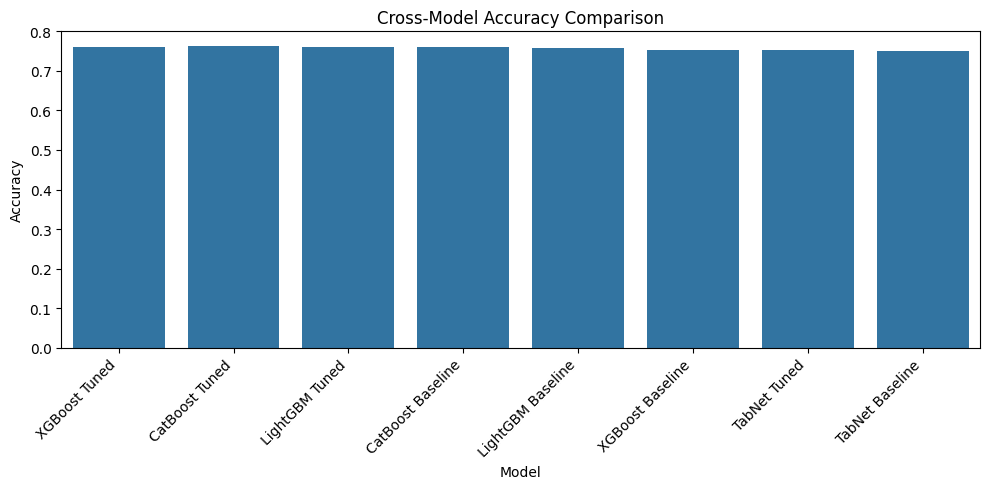

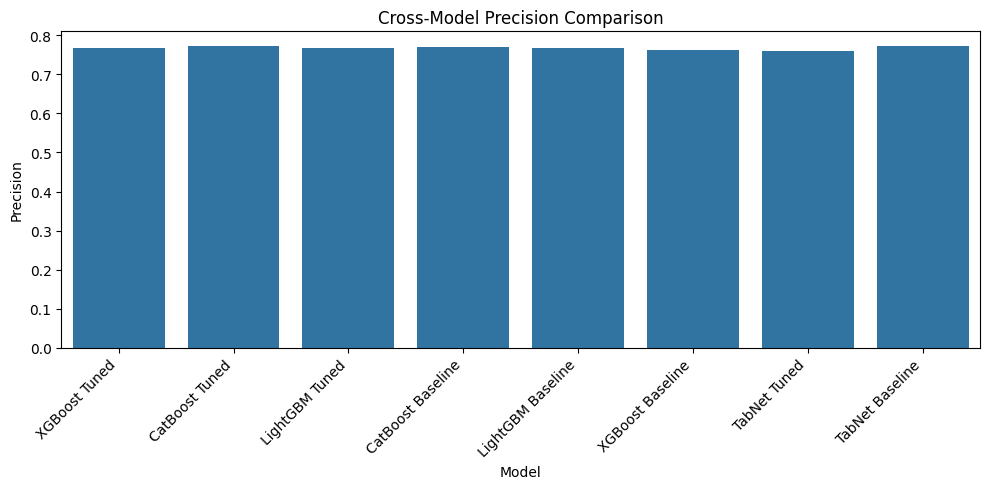

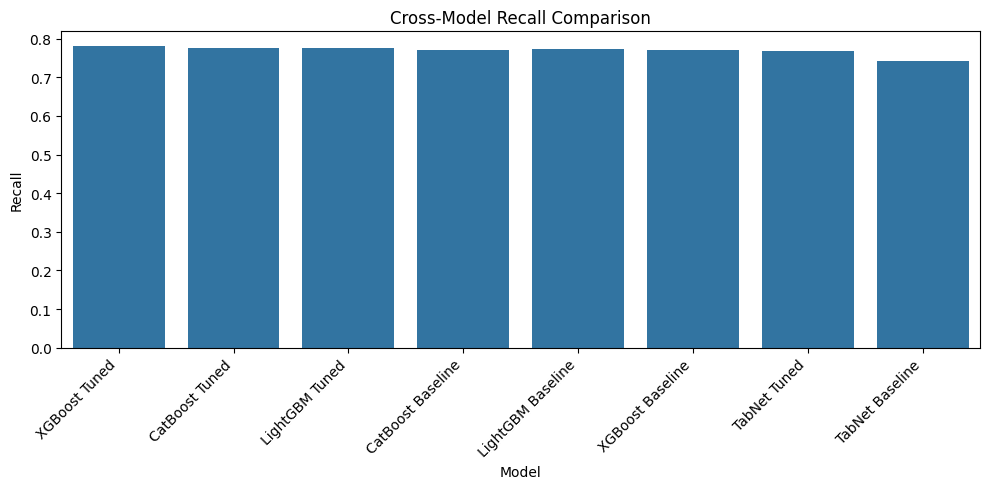

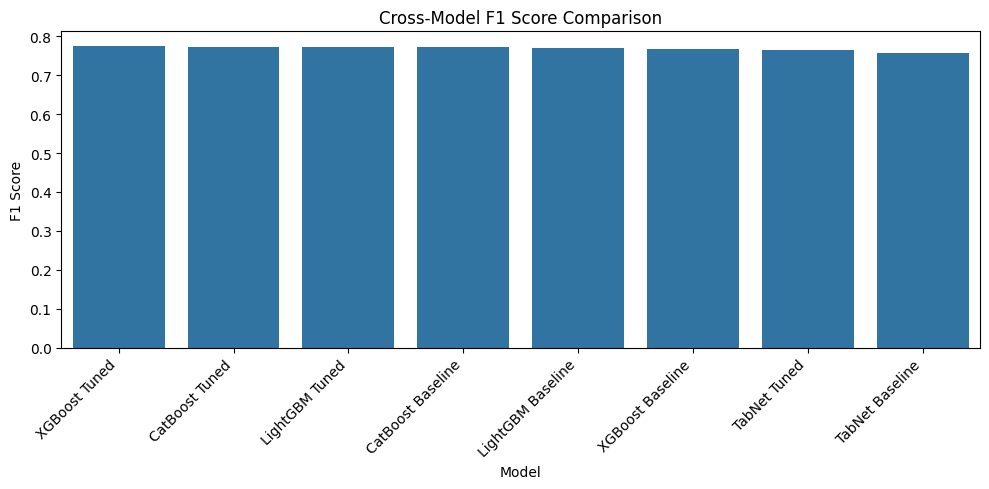

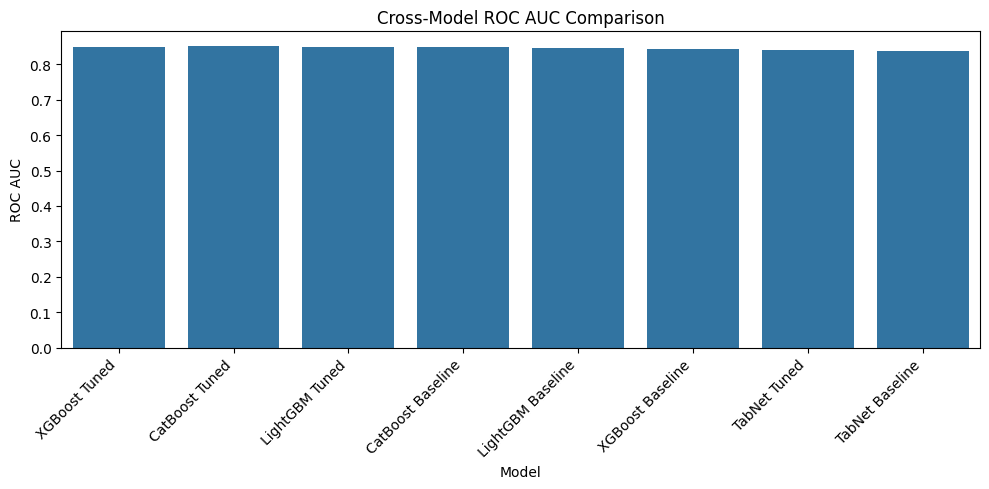

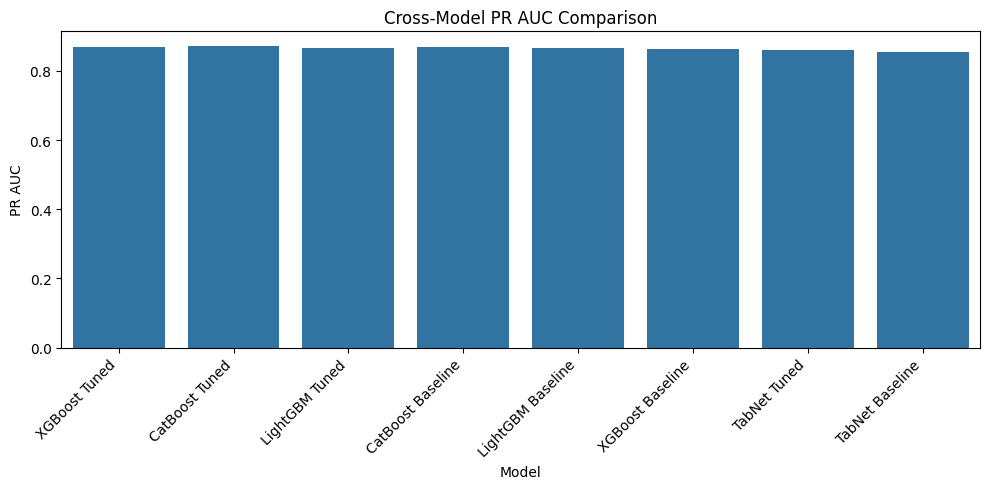

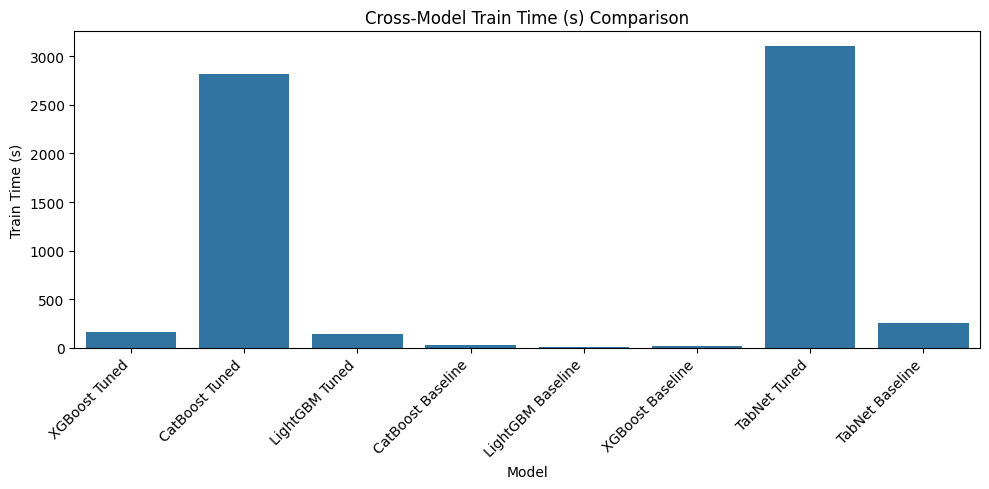

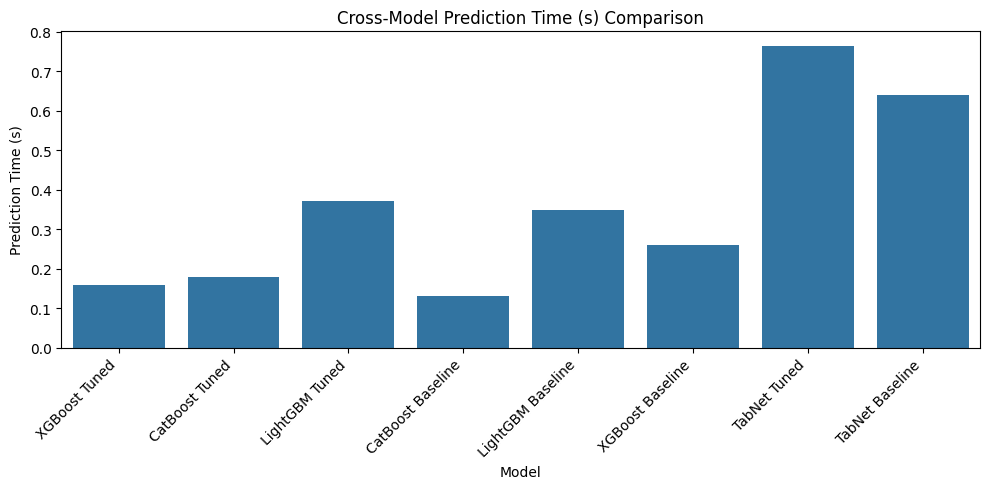

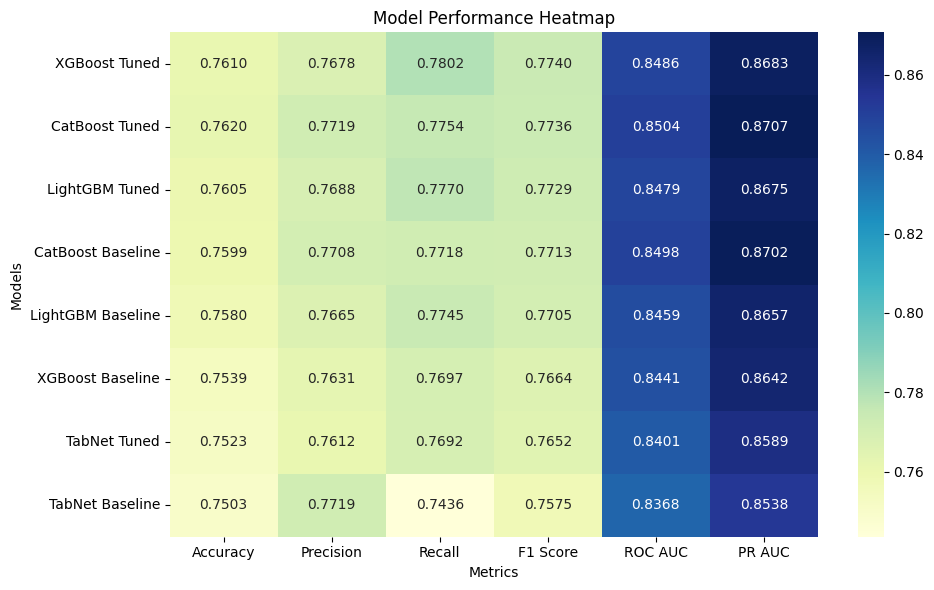

Best model object loaded successfully: XGBoost Tuned


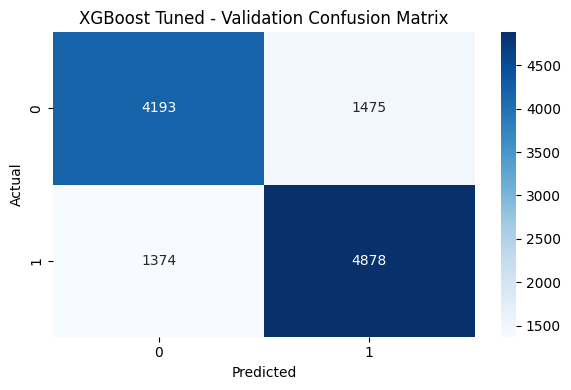

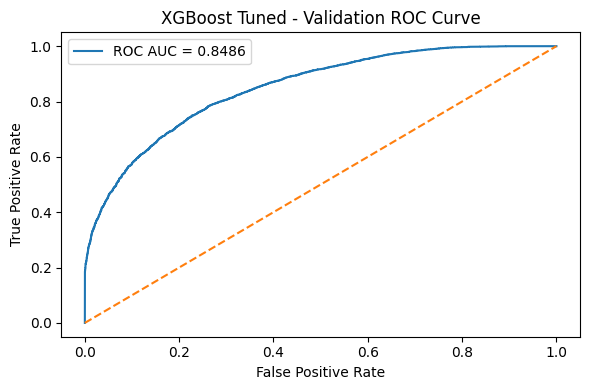

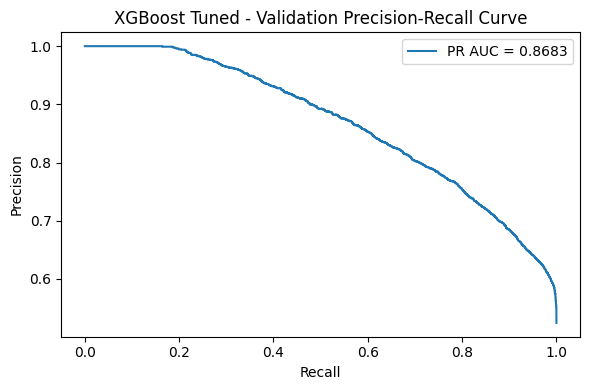

Validation actual vs predicted class counts:


,Actual,Predicted
0,5668,5567
1,6252,6353


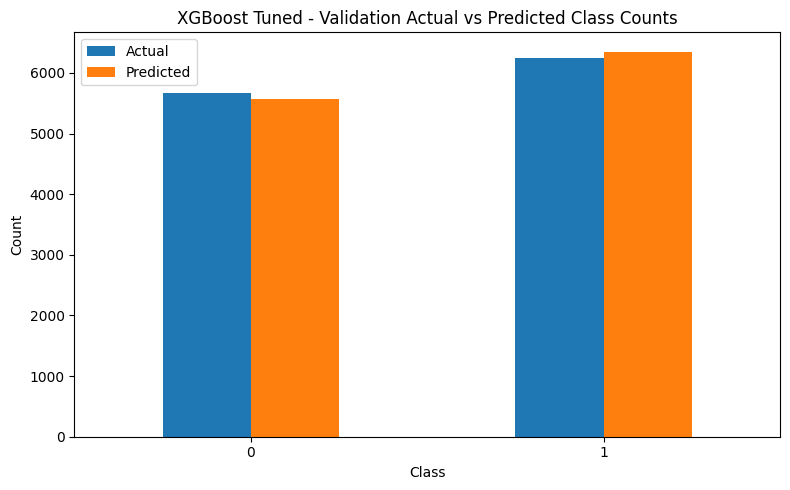

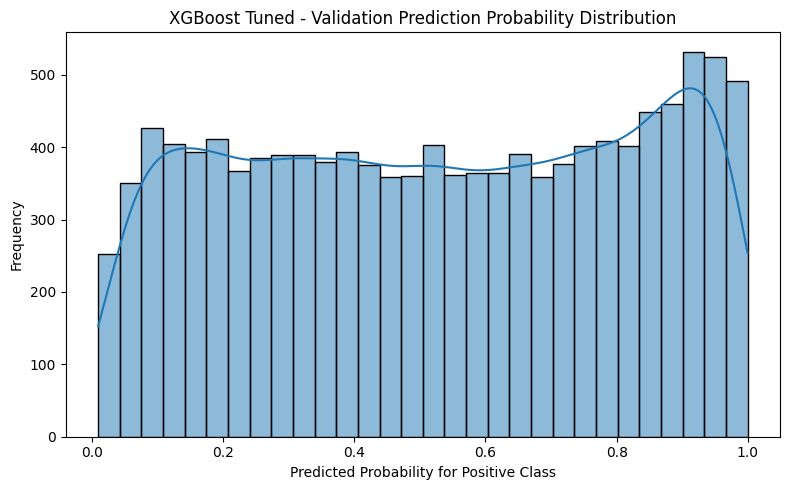

Top 15 important features of best model:


,Feature,Importance
15,Job Level,0.189089
14,Marital Status,0.163124
17,Remote Work,0.128083
9,Work-Life Balance,0.068457
3,Number of Promotions,0.062162
7,Gender,0.057651
13,Education Level,0.055456
5,Number of Dependents,0.049394
20,Company Reputation,0.037765
12,Overtime,0.030040


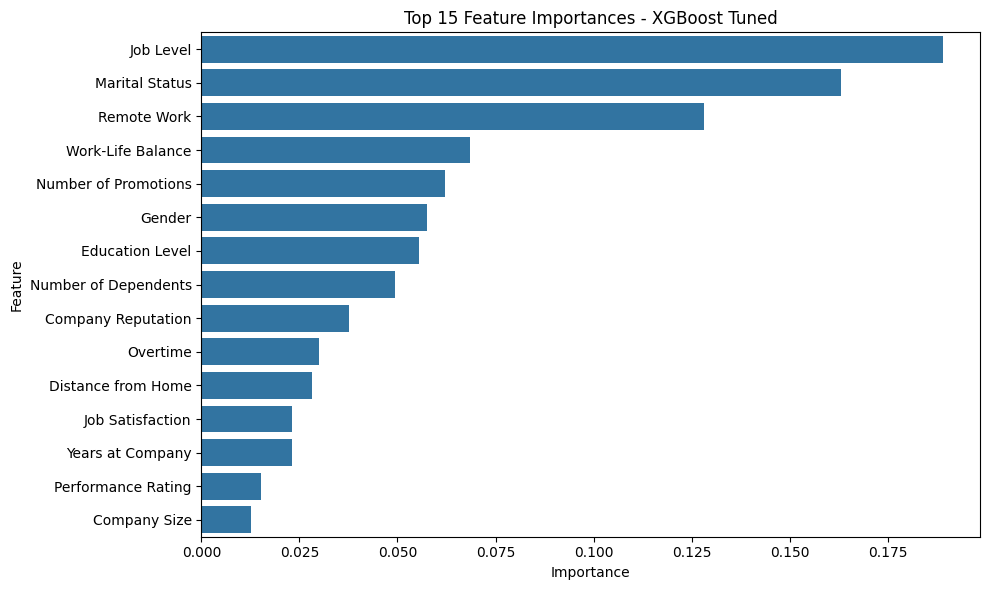

Final test prediction completed for: XGBoost Tuned
Prediction shape: (14900,)
Final test results:


,Best Model,Test Accuracy,Test Precision,Test Recall,Test F1 Score,Test ROC AUC,Test PR AUC
0,XGBoost Tuned,0.762013,0.773337,0.777072,0.7752,0.85231,0.873188


Classification Report - Final Best Model on Test Set
              precision    recall  f1-score   support

           0       0.75      0.75      0.75      7032
           1       0.77      0.78      0.78      7868

    accuracy                           0.76     14900
   macro avg       0.76      0.76      0.76     14900
weighted avg       0.76      0.76      0.76     14900



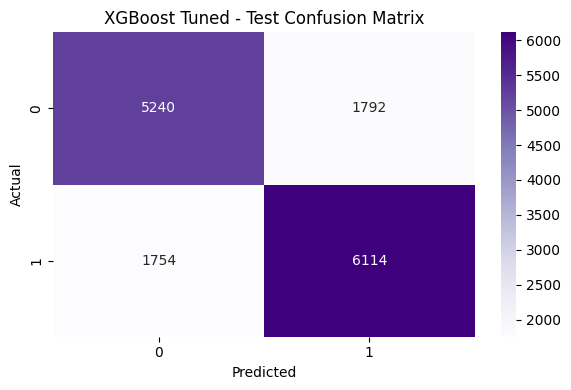

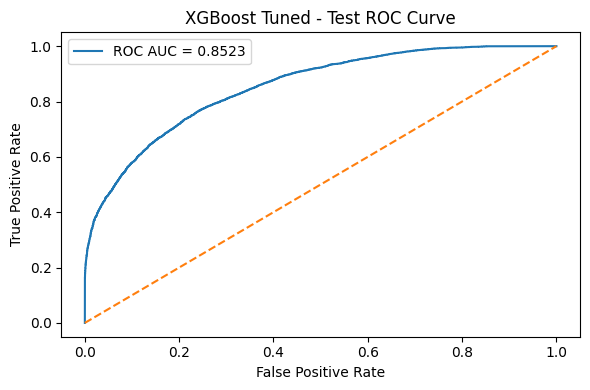

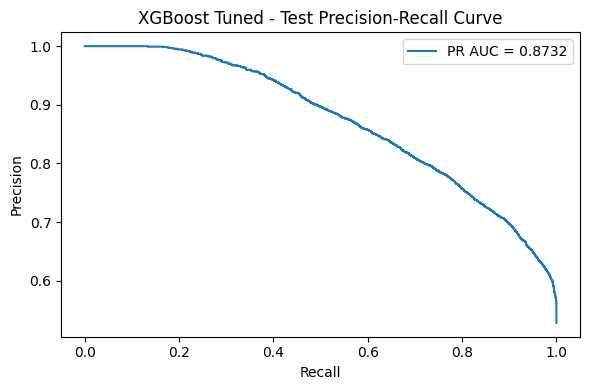

Test actual vs predicted class counts:


,Actual,Predicted
0,7032,6994
1,7868,7906


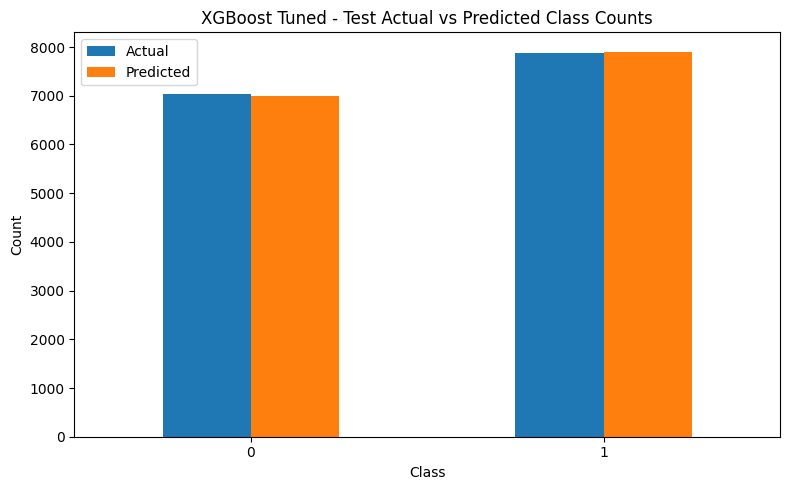

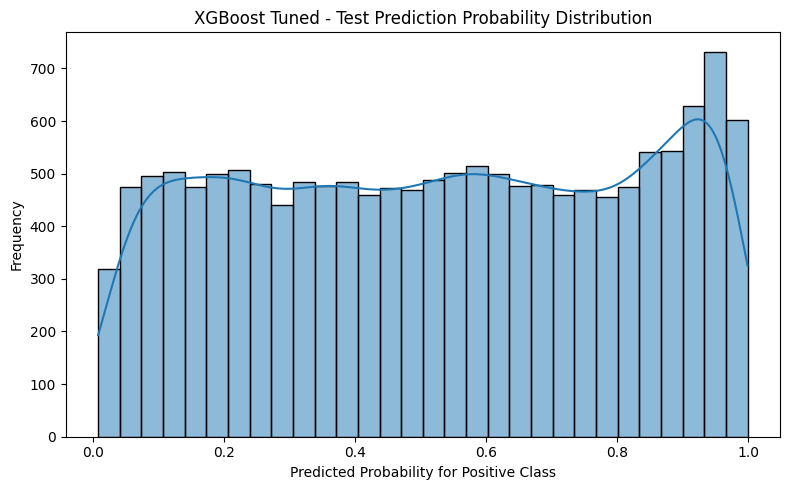

Exported:
- all_model_results.csv
- all_model_results_ranked.csv
- best_model_test_results.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Combine all model results
all_model_results = pd.concat([
    xgb_baseline_results,
    xgb_tuned_results,
    lgb_baseline_results,
    lgb_tuned_results,
    cat_baseline_results,
    cat_tuned_results,
    tabnet_baseline_results,
    tabnet_tuned_results
], ignore_index=True)

print("Combined results table:")
display(all_model_results)

# Priority: F1 > Recall > PR AUC > ROC AUC > Accuracy > Precision
results_ranked = all_model_results.copy()

results_ranked = results_ranked.sort_values(
    by=["F1 Score", "Recall", "PR AUC", "ROC AUC", "Accuracy", "Precision"],
    ascending=[False, False, False, False, False, False]
).reset_index(drop=True)

results_ranked.insert(0, "Final Rank", range(1, len(results_ranked) + 1))

print("Final ranked results:")
display(results_ranked)

best_model_row = results_ranked.iloc[0]
best_model_name = best_model_row["Model"]

print("Selected Best Model:", best_model_name)
display(best_model_row.to_frame().T)

# Metric comparison visuals
metric_columns = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC", "PR AUC"]

for metric in metric_columns:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=results_ranked, x="Model", y=metric)
    plt.title(f"Cross-Model {metric} Comparison")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Runtime comparison visuals
time_columns = ["Train Time (s)", "Prediction Time (s)"]

for metric in time_columns:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=results_ranked, x="Model", y=metric)
    plt.title(f"Cross-Model {metric} Comparison")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Heatmap of model metrics
heatmap_df = results_ranked.set_index("Model")[[
    "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC", "PR AUC"
]]

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", fmt=".4f")
plt.title("Model Performance Heatmap")
plt.xlabel("Metrics")
plt.ylabel("Models")
plt.tight_layout()
plt.show()

#Load best model object and its validation predictions
model_objects = {
    "XGBoost Baseline": xgb_baseline,
    "XGBoost Tuned": xgb_tuned,
    "LightGBM Baseline": lgb_baseline,
    "LightGBM Tuned": lgb_tuned,
    "CatBoost Baseline": cat_baseline,
    "CatBoost Tuned": cat_tuned,
    "TabNet Baseline": tabnet_baseline,
    "TabNet Tuned": best_tabnet
}

validation_predictions = {
    "XGBoost Baseline": (xgb_baseline_val_pred, xgb_baseline_val_prob),
    "XGBoost Tuned": (xgb_tuned_val_pred, xgb_tuned_val_prob),
    "LightGBM Baseline": (lgb_baseline_val_pred, lgb_baseline_val_prob),
    "LightGBM Tuned": (lgb_tuned_val_pred, lgb_tuned_val_prob),
    "CatBoost Baseline": (cat_baseline_val_pred, cat_baseline_val_prob),
    "CatBoost Tuned": (cat_tuned_val_pred, cat_tuned_val_prob),
    "TabNet Baseline": (tabnet_baseline_val_pred, tabnet_baseline_val_prob),
    "TabNet Tuned": (tabnet_tuned_val_pred, tabnet_tuned_val_prob)
}

best_model = model_objects[best_model_name]
best_val_pred, best_val_prob = validation_predictions[best_model_name]

print("Best model object loaded successfully:", best_model_name)

#Best model validation confusion matrix
cm_val = confusion_matrix(y_val, best_val_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues")
plt.title(f"{best_model_name} - Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

#Best model validation ROC curve
fpr_val, tpr_val, _ = roc_curve(y_val, best_val_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr_val, tpr_val, label=f"ROC AUC = {roc_auc_score(y_val, best_val_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"{best_model_name} - Validation ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

#Best model validation PR curve
precision_val, recall_val, _ = precision_recall_curve(y_val, best_val_prob)

plt.figure(figsize=(6, 4))
plt.plot(recall_val, precision_val, label=f"PR AUC = {average_precision_score(y_val, best_val_prob):.4f}")
plt.title(f"{best_model_name} - Validation Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

#Actual vs predicted class counts on validation set
actual_counts_val = pd.Series(y_val).value_counts().sort_index()
pred_counts_val = pd.Series(best_val_pred).value_counts().sort_index()

comparison_counts_val = pd.DataFrame({
    "Actual": actual_counts_val,
    "Predicted": pred_counts_val
}).fillna(0)

print("Validation actual vs predicted class counts:")
display(comparison_counts_val)

comparison_counts_val.plot(kind="bar", figsize=(8, 5))
plt.title(f"{best_model_name} - Validation Actual vs Predicted Class Counts")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#Prediction probability distribution on validation set
plt.figure(figsize=(8, 5))
sns.histplot(best_val_prob, bins=30, kde=True)
plt.title(f"{best_model_name} - Validation Prediction Probability Distribution")
plt.xlabel("Predicted Probability for Positive Class")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Best model feature importance
if "XGBoost" in best_model_name:
    importance_df_best = pd.DataFrame({
        "Feature": numerical_features + categorical_features,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

elif "LightGBM" in best_model_name:
    importance_df_best = pd.DataFrame({
        "Feature": numerical_features + categorical_features,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

elif "CatBoost" in best_model_name:
    importance_df_best = pd.DataFrame({
        "Feature": X_train_sub_cat.columns,
        "Importance": best_model.get_feature_importance()
    }).sort_values(by="Importance", ascending=False)

elif "TabNet" in best_model_name:
    importance_df_best = pd.DataFrame({
        "Feature": X_train_sub_tabnet.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

print("Top 15 important features of best model:")
display(importance_df_best.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df_best.head(15), x="Importance", y="Feature")
plt.title(f"Top 15 Feature Importances - {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#Final test prediction using selected best model
if best_model_name == "XGBoost Baseline":
    final_test_prob = xgb_baseline.predict_proba(X_test_xgb_lgb)[:, 1]
    final_test_pred = xgb_baseline.predict(X_test_xgb_lgb)

elif best_model_name == "XGBoost Tuned":
    final_test_prob = xgb_tuned.predict_proba(X_test_xgb_lgb)[:, 1]
    final_test_pred = xgb_tuned.predict(X_test_xgb_lgb)

elif best_model_name == "LightGBM Baseline":
    final_test_prob = lgb_baseline.predict_proba(X_test_xgb_lgb)[:, 1]
    final_test_pred = lgb_baseline.predict(X_test_xgb_lgb)

elif best_model_name == "LightGBM Tuned":
    final_test_prob = lgb_tuned.predict_proba(X_test_xgb_lgb)[:, 1]
    final_test_pred = lgb_tuned.predict(X_test_xgb_lgb)

elif best_model_name == "CatBoost Baseline":
    final_test_prob = cat_baseline.predict_proba(X_test_cat)[:, 1]
    final_test_pred = cat_baseline.predict(X_test_cat)
    final_test_pred = pd.Series(final_test_pred).astype(int).values

elif best_model_name == "CatBoost Tuned":
    final_test_prob = cat_tuned.predict_proba(X_test_cat)[:, 1]
    final_test_pred = cat_tuned.predict(X_test_cat)
    final_test_pred = pd.Series(final_test_pred).astype(int).values

elif best_model_name == "TabNet Baseline":
    final_test_prob = tabnet_baseline.predict_proba(X_test_tabnet_np)[:, 1]
    final_test_pred = (final_test_prob >= 0.5).astype(int)

elif best_model_name == "TabNet Tuned":
    final_test_prob = best_tabnet.predict_proba(X_test_tabnet_np)[:, 1]
    final_test_pred = (final_test_prob >= 0.5).astype(int)

print("Final test prediction completed for:", best_model_name)
print("Prediction shape:", final_test_pred.shape)

#Final test metrics
best_model_test_results = pd.DataFrame([{
    "Best Model": best_model_name,
    "Test Accuracy": accuracy_score(y_test, final_test_pred),
    "Test Precision": precision_score(y_test, final_test_pred),
    "Test Recall": recall_score(y_test, final_test_pred),
    "Test F1 Score": f1_score(y_test, final_test_pred),
    "Test ROC AUC": roc_auc_score(y_test, final_test_prob),
    "Test PR AUC": average_precision_score(y_test, final_test_prob)
}])

print("Final test results:")
display(best_model_test_results)

print("Classification Report - Final Best Model on Test Set")
print(classification_report(y_test, final_test_pred))

#Final test confusion matrix
cm_test = confusion_matrix(y_test, final_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Purples")
plt.title(f"{best_model_name} - Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

#Final test ROC curve
fpr_test, tpr_test, _ = roc_curve(y_test, final_test_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr_test, tpr_test, label=f"ROC AUC = {roc_auc_score(y_test, final_test_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"{best_model_name} - Test ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

#Final test PR curve
precision_test, recall_test, _ = precision_recall_curve(y_test, final_test_prob)

plt.figure(figsize=(6, 4))
plt.plot(recall_test, precision_test, label=f"PR AUC = {average_precision_score(y_test, final_test_prob):.4f}")
plt.title(f"{best_model_name} - Test Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

# Actual vs predicted class counts on test set
actual_counts_test = pd.Series(y_test).value_counts().sort_index()
pred_counts_test = pd.Series(final_test_pred).value_counts().sort_index()

comparison_counts_test = pd.DataFrame({
    "Actual": actual_counts_test,
    "Predicted": pred_counts_test
}).fillna(0)

print("Test actual vs predicted class counts:")
display(comparison_counts_test)

comparison_counts_test.plot(kind="bar", figsize=(8, 5))
plt.title(f"{best_model_name} - Test Actual vs Predicted Class Counts")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#Test prediction probability distribution
plt.figure(figsize=(8, 5))
sns.histplot(final_test_prob, bins=30, kde=True)
plt.title(f"{best_model_name} - Test Prediction Probability Distribution")
plt.xlabel("Predicted Probability for Positive Class")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#Save final tables
all_model_results.to_csv("all_model_results.csv", index=False)
results_ranked.to_csv("all_model_results_ranked.csv", index=False)
best_model_test_results.to_csv("best_model_test_results.csv", index=False)

print("Exported:")
print("- all_model_results.csv")
print("- all_model_results_ranked.csv")
print("- best_model_test_results.csv")